# Deep Learning for the HJB Equation — Hard-BC + Power-of-Affine Ansatz (CRRA, $\gamma \neq 1$)

## Master's Thesis — Cecilia Trojani (UZH / ETH, 2025–2026)

---

This notebook solves the homogeneous Blanchard OLG HJB equation under CRRA
preferences $u(c) = (c^{1-\gamma}-1)/(1-\gamma)$ (default $\gamma = 2$) using
a physics-informed neural network (PINN) with a **hard boundary condition**
built into the architecture and **FOC-substituted controls**, in which
optimal consumption and portfolio are eliminated analytically from the
Bellman equation via the CRRA first-order conditions rather than learned by
separate policy heads. The rescaled utility form is used so that the
$\gamma \to 1$ limit reduces continuously to log utility; the resulting
additive constant is absorbed into the value-function level $K^{\star}$.

### Overview

- **Architecture.** A power-of-affine trial solution
  $$
  \widehat V(w, y) \;=\; \frac{\phi^{\gamma}}{1-\gamma}\,
                       \Big(w + y \cdot \text{softplus}\bigl(\mathrm{NN}_{\varphi}(w, y)\bigr)\Big)^{1-\gamma}
                       \;-\; \frac{1}{(1-\gamma)\,\delta}
  $$
  exactly matches the closed-form structure
  $V^{\star} = \tfrac{\phi^{\gamma}}{1-\gamma}(w + \varphi_e\, y)^{1-\gamma} + K^{\star}$
  with the constant collateral coefficient $\varphi_e$ replaced by the
  strictly positive learnable function
  $\text{softplus}(\mathrm{NN}_{\varphi}(w, y))$.
  Because $y_{\min} = 0$, the trial solution reduces to
  $V_{BC}(w) = \tfrac{\phi^{\gamma}}{1-\gamma}\, w^{1-\gamma} + K^{\star}$
  at the boundary $y = 0$ for any network output, so the homogeneous boundary
  condition is satisfied **architecturally** without any penalty term.
  Optimal controls are eliminated from the Bellman equation via the CRRA
  first-order conditions
  $c = V_w^{-1/\gamma}$
  and the analytical mean-variance portfolio rule with labour-income hedge
  $\pi = -\bigl(V_w(\mu^S - r) + V_{wy}\,\sigma_S \sigma_Y\, y\bigr)
            \big/ (V_{ww}\, \sigma_S^2)$,
  both evaluated by autograd through the trained $V$.

- **Training pipeline (two phases, no warm-up).**
  - *Phase 1.* Adam in FP64, 30,000 epochs at learning rate $10^{-4}$ constant
    throughout (a `MultiStepLR` is registered but its milestones are placed
    out of range, so no decay fires). Starts from a random Xavier
    initialisation.
  - *Phase 2.* L-BFGS in FP64 with strong-Wolfe line search on a
    residual-weighted frozen grid of 16,000 collocation points (sampled by
    importance from a 60,000-point candidate pool), max $100$ outer
    iterations, stagnation tolerance $10^{-14}$ sustained for $10$ consecutive
    steps.

- **Loss components.** Bellman residual (FOC-substituted, not learned-policy)
  plus a minimal shape penalty enforcing $V_w > 0$ and $V_y > 0$. FOC-stability
  clamps $V_w \ge 10^{-4}$ and $V_{ww} \le -10^{-3}$ keep the optimal controls
  well-defined during the early-training transient before concavity is
  established globally.

- **Validation.** The closed-form OLG value $V^{\star}(w, y)$ and policies
  $c^{\star},\, \pi^{\star}$ are used only post-hoc on a regular grid. They
  never enter any training loss.


---
## Cell 0 — Imports, reproducibility, default precision, and domain bounds

Boilerplate that every subsequent cell depends on:

- **Standard scientific stack.** NumPy, matplotlib, and PyTorch
  (`torch`, `nn`, `F`, `optim`).
- **Reproducibility.** Fixed RNG seeds (42) for both PyTorch — controlling
  NN initialisation and collocation resampling — and NumPy, controlling the
  closed-form validation grid.
- **Default precision = FP64.** CRRA derivatives are stiff: the FOC substitutes
  $c = V_w^{-1/\gamma}$ and $\pi$ through $1/V_{ww}$, both of which amplify
  round-off. FP32 leaves visible residual noise on the L-BFGS polish, so we
  run FP64 throughout Phase 1 and Phase 2 (unlike the log-utility notebook,
  which used FP32 in Phase 1 and FP64 only in Phase 2).
- **Device.** CUDA if available, otherwise CPU.
- **Domain.** Rectangular state space
  $[w_{\min},\, w_{\max}] \times [y_{\min},\, y_{\max}] = [0.01,\, 8.0] \times [0,\, 2.5]$.
  Setting $y_{\min} = 0$ makes the hard-BC anchor exact: the power-of-affine
  ansatz reduces to the closed-form CRRA Merton value
  $\widehat V(w, 0) = \tfrac{\phi^\gamma}{1-\gamma}\, w^{1-\gamma}
   - \tfrac{1}{(1-\gamma)\delta}$
  for any network output.

In [1]:
# =============================================================================
# Cell 0 — Imports, reproducibility, default precision, and domain bounds.
#
# Boilerplate every subsequent cell depends on:
#   • standard scientific Python + PyTorch imports
#   • fixed RNG seeds for deterministic NN init and collocation resampling
#   • FP64 as the default dtype (CRRA HJB derivatives are stiff; FP32 leaves
#     visible noise in V_w^(-1/γ) and 1/V_ww after L-BFGS polish)
#   • device selection (CUDA if available, else CPU)
#   • rectangular state-space bounds [W_MIN, W_MAX] × [Y_MIN, Y_MAX]
# =============================================================================

# ---- Standard scientific stack -------------------------------------------
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ---- Reproducibility -----------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)


# ---- Default precision and device ----------------------------------------
# Use FP64 globally (improves HJB-PINN derivative stability).
# Under CRRA the FOC substitutes c = V_w^(-1/γ) and π through 1/V_ww; both
# amplify round-off and benefit from double precision in both phases.
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}, default dtype: {torch.get_default_dtype()}')


# ---- Domain bounds -------------------------------------------------------
# Wealth     w ∈ [W_MIN, W_MAX] = [0.01, 8.0]
# Labour Y   y ∈ [Y_MIN, Y_MAX] = [0.00, 2.5]
# Y_MIN = 0 is the hard-BC anchor — the power-of-affine ansatz reduces to
# V_hat(w, 0) = (φ^γ/(1-γ)) · w^(1-γ) − 1/((1-γ)δ) for every NN output,
# matching the closed-form CRRA Merton-with-mortality value on the boundary
# by construction.
W_MIN, W_MAX = 0.01, 8.0
Y_MIN, Y_MAX = 0.0,  2.5

Using device: cpu, default dtype: torch.float64


---
## Cell 1 — CRRA economic primitives and closed-form OLG equilibrium constants

Implements Corollary 3.3 (eqs. 3.8–3.16) for the homogeneous Blanchard–Yaari
OLG economy under CRRA preferences with $\gamma \neq 1$. **All equilibrium
constants are $\gamma$-dependent** and must use the CRRA branch; substituting
the log-utility ($\gamma = 1$) formulas while solving the CRRA value function
gives an internally inconsistent economy (mismatched $V^{\star}(1, 1)$, off-FOC
$c^{\star}$, wrong wedge between $\sigma^S$ and $\sigma_Y$).

**What is computed:**

- **Primitives.** $\rho,\, \nu,\, \mu_Y,\, \sigma_Y,\, \omega,\, \sigma^S = \sigma_Y$,
  and $\delta = \rho + \nu = 0.07$.
- **Newborn consumption share $\beta(\gamma)$.** Smaller (economically
  meaningful) root of the quadratic implied by market clearing
  (eqs. 3.9–3.10). Computed via the helper `beta_crra(g)`.
- **Equilibrium short rate $r$** (eq. 3.8), market price of risk
  $\theta = \gamma \sigma_Y$, and stock drift $\mu^S = r + \theta \sigma^S$
  (Euler equation).
- **Wealth-to-consumption ratio $\varphi$** (eq. 3.11) and the wage / dividend
  capitalizations $\varphi^e,\, \varphi^d$ (eqs. 3.12–3.13). The print block
  verifies the identity $\varphi = \varphi^e + \varphi^d$ (eq. 3.14) as a
  sanity check on the closed-form derivation.
- **Ansatz constants.** $\varphi^{\gamma}$ (`PHI_GAMMA`, the prefactor used in
  the Cell 2 architecture) and $K^{\star} = -1/((1-\gamma)\delta)$ (the
  additive shift that makes the CRRA homogeneity identity
  $wV_w + yV_y = (1-\gamma)V + 1/\delta$ hold exactly).

**Closed-form helpers** `V_true(w, y)`, `c_true(w, y)`, `pi_true(w, y)` are
defined for post-hoc validation only — they never enter any training loss.
The portfolio formula $\pi^{\star}(w, y) = (\mu^S - r)/(\gamma \sigma_S^2) \cdot A - \varphi^e \sigma_Y y / \sigma_S$
with $A = w + \varphi^e y$ keeps $\sigma_Y / \sigma_S$ explicit, since under
CRRA at $\gamma \neq 1$ this ratio is **not** generically 1 (it equals 1 here
only because eq. 3.15 imposes $\sigma^S = \sigma_Y$).


In [2]:
# =============================================================================
# Cell 1 — CRRA economic primitives and closed-form OLG equilibrium constants
# (Thesis Corollary 3.3, eqs. 3.8–3.16).
#
# CRRA branch (γ ≠ 1): the equilibrium short rate r, newborn consumption share
# β, wealth-to-consumption ratio φ, and wage / dividend capitalizations
# (φ^e, φ^d) all depend on γ. Substituting the log (γ = 1) formulas while
# solving the CRRA value function gives an inconsistent economy — mismatched
# V*(1, 1), off-FOC c*, wrong wedge between σ_S and σ_Y. This cell implements
# the γ-dependent closed forms and uses them only for post-hoc validation;
# they never enter any training loss.
# =============================================================================

# ---- Risk aversion -------------------------------------------------------
GAMMA = 2.0                 # CRRA risk aversion (γ ≠ 1 branch)
gamma = GAMMA               # legacy alias used throughout the rest of the code


# ---- Primitives ----------------------------------------------------------
rho   = 0.05                # subjective discount rate
nu    = 0.02                # constant Blanchard-Yaari death rate
mu_Y  = 0.02                # mean growth of labour productivity Y
sig_Y = 0.10                # volatility of labour productivity Y
omega = 0.70                # wage share of capital income
sig_S = sig_Y               # eq. 3.15: σ^S = σ_Y  (single-shock economy)
delta = rho + nu            # effective discount rate δ = ρ + ν = 0.07


# ---- Corollary 3.3: CRRA homogeneous equilibrium prices ------------------
def beta_crra(g):
    """Return the CRRA-equilibrium newborn consumption share β(γ).

    Smaller (economically meaningful) root of the quadratic in β implied by
    the homogeneous-economy market-clearing condition (eqs. 3.9–3.10).

    Args:
        g : risk-aversion coefficient γ (must satisfy γ > 0, γ ≠ 1)
    Returns:
        β : scalar in (0, 1)
    """
    A_g = rho + (g - 1.0) * mu_Y - 0.5 * g * (g - 1.0) * sig_Y**2 + nu * (1.0 + g + omega * (g - 1.0))
    B_g = rho + (g - 1.0) * mu_Y - 0.5 * g * (g - 1.0) * sig_Y**2 + g * nu
    disc = A_g**2 - 4.0 * g * nu * omega * B_g
    return (A_g - np.sqrt(disc)) / (2.0 * g * nu)

beta_cf = beta_crra(GAMMA)                                                    # β (eqs. 3.9–3.10)

# Equilibrium short rate (eq. 3.8)
r_cf = rho + GAMMA * mu_Y - 0.5 * GAMMA * (GAMMA + 1.0) * sig_Y**2 + GAMMA * nu * (1.0 - beta_cf)

# Market price of risk and stock drift (eq. 3.8 + Euler equation)
theta_eq = GAMMA * sig_Y                                                       # θ = γ σ_Y
mu_S     = r_cf + theta_eq * sig_S                                             # μ^S = r + θ σ^S

# Wealth-to-consumption ratio (eq. 3.11)
phi_cf = 1.0 / (nu + rho / GAMMA + ((GAMMA - 1.0) / GAMMA) * r_cf + 0.5 * (GAMMA - 1.0) * sig_Y**2)

# Wage and dividend capitalizations (eqs. 3.12–3.13)
phi_e = omega         / (r_cf + nu - mu_Y + GAMMA * sig_Y**2)                  # φ^e (wage)
phi_d = (1.0 - omega) / (r_cf      - mu_Y + GAMMA * sig_Y**2)                  # φ^d (dividend)

# Value-function ansatz constants (matched to the Cell 2 architecture)
PHI_GAMMA = phi_cf ** GAMMA                                                    # prefactor φ^γ
K_star    = -1.0 / ((1.0 - GAMMA) * delta)                                     # additive shift K* = −1/((1−γ)δ)


# ---- Closed-form V*, c*, π* (CRRA branch, γ ≠ 1) -------------------------
def V_true(w_np, y_np):
    """Closed-form V*(w, y) for the homogeneous CRRA OLG economy.

        V*(w, y) = (φ^γ / (1 − γ)) · (w + φ^e y)^(1 − γ)  +  K*

    Used post-hoc on a validation grid only. Never enters any training loss.

    Args:
        w_np, y_np : numpy arrays of equal shape
    Returns:
        V*(w, y)   : numpy array, same shape as inputs
    """
    what = np.clip(w_np + phi_e * y_np, 1e-30, None)                           # guard A → 0
    return (PHI_GAMMA / (1.0 - GAMMA)) * what ** (1.0 - GAMMA) + K_star


def c_true(w_np, y_np):
    """Closed-form c*(w, y) = (w + φ^e y) / φ   (eq. 3.16, CRRA branch)."""
    return (w_np + phi_e * y_np) / phi_cf


def pi_true(w_np, y_np):
    """Closed-form π*(w, y) derived from FOC with
        V* = (φ^γ / (1 − γ)) · (w + φ^e y)^(1 − γ)  +  K*.

    Derivatives at (w, y), with A ≔ w + φ^e y:
        V*_w   =     φ^γ          · A^(−γ)
        V*_ww  = − γ φ^γ          · A^(−γ−1)
        V*_wy  = − γ φ^γ · φ^e    · A^(−γ−1)

      ⇒  π*(w, y) = (μ^S − r) / (γ σ_S²) · A  −  φ^e σ_Y y / σ_S
    """
    A = w_np + phi_e * y_np
    return (mu_S - r_cf) / (GAMMA * sig_S ** 2) * A - phi_e * sig_Y * y_np / sig_S


# ---- Sanity prints --------------------------------------------------------
print("=== CRRA OLG homogeneous equilibrium (Corollary 3.3) ===")
print(f"  γ          = {GAMMA}")
print(f"  β          = {beta_cf:.5f}        (eq. 3.9)")
print(f"  r          = {r_cf:.5f}        (eq. 3.8)")
print(f"  θ          = {theta_eq:.5f}        (eq. 3.8: θ = γσ_Y)")
print(f"  μ^S        = {mu_S:.5f}")
print(f"  σ^S        = {sig_S:.5f}        (eq. 3.15)")
print(f"  φ          = {phi_cf:.5f}        (eq. 3.11)")
print(f"  φ^e        = {phi_e:.5f}        (eq. 3.12)")
print(f"  φ^d        = {phi_d:.5f}        (eq. 3.13)")
print(f"  φ^e + φ^d  = {phi_e + phi_d:.5f}        (should equal φ; eq. 3.14)")
print(f"  φ^γ        = {PHI_GAMMA:.5f}        (V-prefactor)")
print(f"  K*         = {K_star:+.5f}        (additive constant −1/((1−γ)δ))")

print()
print("=== Closed-form benchmark values at (w, y) = (1, 1) ===")
print(f"  V*(1, 1)   = {V_true(1.0, 1.0):+.5f}")
print(f"  c*(1, 1)   = {c_true(1.0, 1.0):+.5f}")
print(f"  π*(1, 1)   = {pi_true(1.0, 1.0):+.5f}")

=== CRRA OLG homogeneous equilibrium (Corollary 3.3) ===
  γ          = 2.0
  β          = 0.64756        (eq. 3.9)
  r          = 0.07410        (eq. 3.8)
  θ          = 0.20000        (eq. 3.8: θ = γσ_Y)
  μ^S        = 0.09410
  σ^S        = 0.10000        (eq. 3.15)
  φ          = 11.48782        (eq. 3.11)
  φ^e        = 7.43910        (eq. 3.12)
  φ^d        = 4.04872        (eq. 3.13)
  φ^e + φ^d  = 11.48782        (should equal φ; eq. 3.14)
  φ^γ        = 131.96999        (V-prefactor)
  K*         = +14.28571        (additive constant −1/((1−γ)δ))

=== Closed-form benchmark values at (w, y) = (1, 1) ===
  V*(1, 1)   = -1.35221
  c*(1, 1)   = +0.73461
  π*(1, 1)   = +1.00000


---

## Cell 2 — HardBC_Net: power-of-affine ansatz network (CRRA branch)

The value-function architecture. ResNet backbone with SiLU activations and
log-$w$ input normalisation, wrapped in the CRRA power-of-affine trial
solution

$$
\widehat V(w, y) \;=\; \frac{\varphi^{\gamma}}{1-\gamma}\,
   \Big(w + y \cdot \mathrm{softplus}\big(\mathrm{NN}_{\varphi}(w, y)\big)\Big)^{1-\gamma}
   + K^{\star}, \qquad K^{\star} = -\tfrac{1}{(1-\gamma)\delta}.
$$

**Three output heads.**

- `NN[0]` — passed through softplus to give the local wage-capitalisation
  function $\mathrm{softplus}(\mathrm{NN}[0])$ that plays the role of
  $\varphi^e$ in the closed form. Used by `forward()` to build $\widehat V$.
- `NN[1], NN[2]` — provide the NN-direct policy corrections
  $c = c_{\mathrm{BC}}(w) + y \cdot \mathrm{softplus}(\mathrm{NN}[1])$ and
  $\pi = \pi_{\mathrm{BC}}(w) + y \cdot \mathrm{NN}[2]$ in
  `forward_policies()`. Under the FOC-substituted residual used in Phase 1/2
  these heads receive no gradient and stay at initialisation; they are
  exposed for downstream code that may train them explicitly.

**Hard BC at $y = 0$.** At $y = 0$ the inner factor reduces to $w$, so
$\widehat V(w, 0) = (\varphi^{\gamma}/(1-\gamma)) w^{1-\gamma} + K^{\star} = V_{\mathrm{BC}}(w)$
for any NN output. The BC is enforced architecturally, not by penalty.

**Small-$w$ regularisation.** In the interior ($y > 0$) the effective wealth
$w + y \cdot \mathrm{softplus}(\mathrm{NN}_{\varphi})$ is bounded below by
$y \cdot \mathrm{softplus}(\mathrm{NN}_{\varphi}) > 0$, so
$V_w \propto w_{\mathrm{eff}}^{-\gamma}$ stays bounded as $w \to 0$. This
dissolves the small-$w$ portfolio spike that a bare additive ansatz would
inherit from $V_{\mathrm{BC}}$'s $\varphi^{\gamma} w^{-\gamma}$ singularity —
a methodologically important property under CRRA, where the Merton boundary
control diverges much faster than under log utility.

**Why SiLU and not Tanh.** Tanh's second derivative is oscillatory, which
makes $V_{ww}$ noisy and destabilises both the FOC-substituted HJB residual
and the concavity component of the shape penalty. SiLU's smooth $f''$ gives
clean $V_{ww}$ throughout training.

**Sanity diagnostics printed by the cell.**

- *Init sanity table.* For each probe point reports $\widehat V$,
  $V_{\mathrm{BC}}$, $V^{\star}$, and the softplus output. The `diff to BC`
  column equals zero (to machine precision) at $y = 0$ — a quick verification
  that the architecture honours the hard BC.
- *Concavity check at init.* Autograd-based table of $V_{ww}, V_{yy}, V_{wy}$
  and $\det H$ at four interior points. Violations at init are expected
  (untrained random weights) and will be removed by the 8-component shape
  penalty during Phase 1.

In [3]:
# =============================================================================
# Cell 2 — HardBC_Net: ResNet backbone + power-of-affine ansatz (CRRA branch).
#
# Three-output network whose head[0] feeds the V-ansatz and heads [1], [2]
# provide optional NN-direct policy corrections. SiLU activations give clean
# V_ww; log-w input normalisation preserves resolution near w → 0; the
# power-of-affine wrapper enforces the y = 0 boundary condition by
# construction.
# =============================================================================
import math


class HardBC_Net(nn.Module):
    """ResNet + log-w normalisation + SiLU (CRRA power-of-affine ansatz).

    Trial solution (CRRA, γ ≠ 1):

        V_hat(w, y) = (φ^γ / (1 − γ)) · (w + y · softplus(NN[0]))^(1 − γ)
                       + K*,            K* = − 1 / ((1 − γ) δ).

    Hard BC at y = 0:
        at y = 0 the inner factor reduces to w, so
        V_hat(w, 0) = (φ^γ / (1 − γ)) · w^(1 − γ) + K* = V_BC(w)
        holds for ANY NN output (BC is enforced architecturally, not by loss).

    Why SiLU and not Tanh:
        Tanh's second derivative is oscillatory, which makes V_ww noisy
        and destabilises both the FOC-substituted HJB residual and the
        concavity component of the shape penalty. SiLU's smooth f''(x)
        gives clean V_ww throughout training.
    """

    def __init__(self, hidden_dim=96, n_layers=6):
        super().__init__()

        # ---- Closed-form constants captured at construction (γ-dependent) -
        self.gamma      = float(GAMMA)
        self.PHI_GAMMA  = float(PHI_GAMMA)
        self.K_star     = float(K_star)
        self.delta      = delta
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers
        self.r_cf       = r_cf
        self.mu_S       = mu_S
        self.sig_S      = sig_S

        # ---- Domain bounds as non-trainable buffers ----------------------
        self.register_buffer('w_min', torch.tensor(W_MIN))
        self.register_buffer('w_max', torch.tensor(W_MAX))
        self.register_buffer('y_min', torch.tensor(Y_MIN))
        self.register_buffer('y_max', torch.tensor(Y_MAX))

        # ---- Backbone: embed → n_layers ResNet blocks → 3-output head ---
        self.embed  = nn.Linear(2, hidden_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])
        self.acts = nn.ModuleList([nn.SiLU() for _ in range(n_layers)])
        self.head = nn.Linear(hidden_dim, 3)

        # ---- Xavier initialisation ---------------------------------------
        for m in [self.embed] + list(self.blocks) + [self.head]:
            for layer in (m if isinstance(m, nn.Sequential) else [m]):
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

    # -------------------------------------------------------------------------
    # Boundary controls at y = 0 (closed-form Merton-CRRA limits)
    # -------------------------------------------------------------------------
    def V_BC(self, w):
        """1D Merton-CRRA boundary value at y = 0:
            V_BC(w) = (φ^γ / (1 − γ)) · w^(1 − γ)  +  K*.
        """
        return (self.PHI_GAMMA / (1.0 - self.gamma)) * w.pow(1.0 - self.gamma) + self.K_star

    def c_BC(self, w):
        """Merton-CRRA optimal consumption at y = 0:  c = w / φ.
        (FOC c = V_w^(−1/γ) with V_w = φ^γ · w^(−γ)  ⇒  c = w / φ.)
        """
        return w / phi_cf

    def pi_BC(self, w):
        """Merton-CRRA optimal portfolio at y = 0:  π = (μ^S − r) / (γ σ_S²) · w."""
        return (self.mu_S - self.r_cf) / (self.gamma * self.sig_S ** 2) * w

    # -------------------------------------------------------------------------
    # Backbone with log-w input normalisation
    # -------------------------------------------------------------------------
    def NN_raw(self, w, y):
        """Forward pass through the embedded ResNet backbone.

        Inputs are mapped to [−1, 1]² before embedding:
            u1 = 2 · (log w − log w_min) / (log w_max − log w_min) − 1
            u2 = 2 · (y     − y_min)     / (y_max     − y_min)     − 1
        Log-w normalisation is critical for small-w resolution: a linear
        normalisation would compress the bulk of the [0.01, 8.0] range into
        a thin sliver near +1.

        Returns the raw 3-channel head output (no softplus / activation).
        """
        log_w     = torch.log(w)
        log_w_min = torch.log(self.w_min)
        log_w_max = torch.log(self.w_max)
        u1 = 2.0 * (log_w - log_w_min) / (log_w_max - log_w_min) - 1.0
        u2 = 2.0 * (y - self.y_min) / (self.y_max - self.y_min) - 1.0
        x  = torch.stack([u1, u2], dim=-1)
        h  = self.embed(x)
        for block, act in zip(self.blocks, self.acts):
            h = act(h + block(h))
        return self.head(h)

    # -------------------------------------------------------------------------
    # Value function (hard-BC trial solution)
    # -------------------------------------------------------------------------
    def forward(self, w, y):
        """Power-of-affine trial solution (CRRA closed-form-structured ansatz):

            V_hat(w, y) = (φ^γ / (1 − γ)) · (w + y · softplus(NN[0]))^(1 − γ)
                          + K*,            K* = −1 / ((1 − γ) δ).

        Hard boundary condition at y = 0:
            inner factor reduces to w, so
            V_hat(w, 0) = (φ^γ / (1 − γ)) · w^(1 − γ) + K* = V_BC(w)
            for ANY NN output (BC enforced independently of training).

        Small-w regularisation (methodological motivation):
            in the interior (y > 0) the effective wealth
                w_eff(w, y) = w + y · softplus(NN[0])
            is bounded below by  y · softplus(NN[0]) > 0,  so
            V_w ∝ φ^γ · w_eff^(−γ) stays bounded as w → 0.  This dissolves
            the small-w portfolio spike that the bare additive ansatz would
            inherit from V_BC's φ^γ w^(−γ) singularity.
        """
        out     = self.NN_raw(w, y)
        phi_hat = F.softplus(out[..., 0])                 # learnable wage capitalisation (positive)
        arg     = w + y * phi_hat                         # effective wealth (> w > 0)
        return (self.PHI_GAMMA / (1.0 - self.gamma)) * arg.pow(1.0 - self.gamma) + self.K_star

    # -------------------------------------------------------------------------
    # NN-direct policies (optional; only used if loss supervises them)
    # -------------------------------------------------------------------------
    def forward_policies(self, w, y):
        """NN-direct policies (Scheidegger-style):
            c (w, y) = c_BC(w)  +  y · softplus(NN[1])
            π (w, y) = π_BC(w)  +  y         · NN[2]
        Under FOC-substituted training (Phase 1/2) heads [1], [2] receive
        no gradient and remain at initialisation; this method is provided
        for downstream code that may train them explicitly.
        """
        out     = self.NN_raw(w, y)
        c_corr  = F.softplus(out[..., 1])
        pi_corr = out[..., 2]
        c  = self.c_BC(w)  + y * c_corr
        pi = self.pi_BC(w) + y * pi_corr
        return c, pi


# ---- Instantiate ---------------------------------------------------------
net = HardBC_Net(hidden_dim=96, n_layers=6).to(device)
n_params = sum(p.numel() for p in net.parameters())


# ---- Network architecture summary ----------------------------------------
print(f'Network: ResNet {net.n_layers} blocks × {net.hidden_dim} (SiLU), CRRA γ = {GAMMA}')
print(f'Architecture: V_hat = (φ^γ/(1-γ)) · (w + y · softplus(NN[0]))^(1-γ) + K*   [CRRA power-of-affine ansatz]')
print(f'  Log-w input normalisation (preserves small-w resolution)')
print(f'  K* = {K_star:+.4f},  Φ = φ^γ = {PHI_GAMMA:.4f},  φ = {phi_cf:.4f}')
print(f'  Hard BC at y = {Y_MIN}: V_hat(w, {Y_MIN}) = V_BC(w) exactly')
print(f'Parameters: {n_params}')


# ---- Init sanity check: V_hat vs V_BC vs V* at probe points --------------
print()
print('=== Init sanity ===')
print(f'   {"(w, y)":<12s} {"V_hat":>10s} {"V_BC":>10s} {"V*":>10s} {"softplus(N)":>12s} {"diff to BC":>11s}')
with torch.no_grad():
    for w_t, y_t in [(1.0, 0.0), (0.5, 0.0), (3.0, 0.0),
                     (1.0, 1.0), (3.0, 1.0), (0.5, 1.0), (1.0, 2.0)]:
        w_pt   = torch.tensor([w_t], device=device)
        y_pt   = torch.tensor([y_t], device=device)
        v_hat  = net(w_pt, y_pt).item()
        v_bc   = net.V_BC(w_pt).item()
        v_star = float(V_true(w_t, y_t))
        sp_N   = F.softplus(net.NN_raw(w_pt, y_pt)[..., 0]).item()
        print(f'   ({w_t}, {y_t})   {v_hat:+10.4f} {v_bc:+10.4f} {v_star:+10.4f}   '
              f'{sp_N:>12.4f} {v_hat - v_bc:>+11.4f}')


# ---- Concavity check at init (soft — penalty will enforce, not structural)
print()
print('=== Concavity check at init (soft — penalty will enforce, not structural) ===')
print(f'   {"(w, y)":<12s} {"Vww":>12s} {"Vyy":>12s} {"Vwy":>12s} {"detH":>12s}    flags')
for w_t, y_t in [(0.5, 0.5), (1.0, 1.0), (3.0, 1.0), (5.0, 2.0)]:
    w_pt = torch.tensor([w_t], device=device, requires_grad=True)
    y_pt = torch.tensor([y_t], device=device, requires_grad=True)
    V    = net(w_pt, y_pt)
    Vw, Vy = torch.autograd.grad(V, [w_pt, y_pt],
                                  grad_outputs=torch.ones_like(V), create_graph=True)
    Vww  = torch.autograd.grad(Vw, w_pt,
                                grad_outputs=torch.ones_like(Vw), create_graph=True)[0].item()
    Vwy  = torch.autograd.grad(Vw, y_pt,
                                grad_outputs=torch.ones_like(Vw), create_graph=True)[0].item()
    Vyy  = torch.autograd.grad(Vy, y_pt,
                                grad_outputs=torch.ones_like(Vy))[0].item()
    detH = Vww * Vyy - Vwy ** 2
    flags = []
    if Vww > 0: flags.append('Vww>0')
    if Vyy > 0: flags.append('Vyy>0')
    if detH < 0: flags.append('det<0')
    flag_str = ', '.join(flags) if flags else 'OK'
    print(f'   (w={w_t}, y={y_t})   {Vww:>+12.4e} {Vyy:>+12.4e} {Vwy:>+12.4e} {detH:>+12.4e}   {flag_str}')

Network: ResNet 6 blocks × 96 (SiLU), CRRA γ = 2.0
Architecture: V_hat = (φ^γ/(1-γ)) · (w + y · softplus(NN[0]))^(1-γ) + K*   [CRRA power-of-affine ansatz]
  Log-w input normalisation (preserves small-w resolution)
  K* = +14.2857,  Φ = φ^γ = 131.9700,  φ = 11.4878
  Hard BC at y = 0.0: V_hat(w, 0.0) = V_BC(w) exactly
Parameters: 112323

=== Init sanity ===
   (w, y)            V_hat       V_BC         V*  softplus(N)  diff to BC
   (1.0, 0.0)    -117.6843  -117.6843  -117.6843         0.6869     +0.0000
   (0.5, 0.0)    -249.6543  -249.6543  -249.6543         0.6873     +0.0000
   (3.0, 0.0)     -29.7043   -29.7043   -29.7043         0.6859     +0.0000
   (1.0, 1.0)     -63.7171  -117.6843    -1.3522         0.6919    +53.9672
   (3.0, 1.0)     -21.4661   -29.7043    +1.6438         0.6913     +8.2382
   (0.5, 1.0)     -96.4188  -249.6543    -2.3371         0.6921   +153.2355
   (1.0, 2.0)     -40.9086  -117.6843    +5.9743         0.6955    +76.7756

=== Concavity check at init (soft

---
## Cell 3 — Autograd derivatives and HJB residual (NN-direct policies)

Two workhorses used by every downstream loss term.

- **`compute_all_derivatives(net, w, y)`** — single autograd pass returning
  $V$ and all five partials ($V_w, V_y, V_{ww}, V_{wy}, V_{yy}$), plus the
  `requires_grad`-enabled $w, y$ tensors.

- **`hjb_residual_2d(...)`** — 2D HJB residual using the network's direct
  policies $c_{\mathrm{NN}}, \pi_{\mathrm{NN}}$ (not FOC-extracted). Two
  advantages over the FOC form: (i) no $V_{ww}$ in the denominator, so
  concavity wobble during training cannot blow up the residual — no clamps
  needed; (ii) minimising $|R|^2$ jointly over $V$ and the policy heads
  implicitly enforces both FOCs ($V_w = u'(c)$ and the portfolio FOC) as
  $\partial R / \partial c,\; \partial R / \partial \pi \to 0$.

**Vanishing viscosity.** `eps_visc > 0` adds $-\varepsilon (V_{ww} + V_{yy})$
to guarantee uniqueness of the viscosity solution (Crandall–Lions 1983;
Liu et al. 2023; Shilova et al. 2024).

**Utility convention.** Rescaled CRRA form
$u(c) = (c^{1-\gamma} - 1) / (1 - \gamma)$, which recovers $\log c$ as
$\gamma \to 1$ and matches the additive constant
$K^{\star} = -1/((1-\gamma)\delta)$ in the ansatz.

A sanity check at the end evaluates the residual at three probe points at
random-init weights and confirms it is finite.

In [4]:
# =============================================================================
# Cell 3 — Autograd derivatives and HJB residual (NN-direct policies).
#
# The HJB residual is computed using the network's direct policy outputs
# (c_NN, π_NN) instead of FOC-extracted ones. This eliminates V_ww in the
# denominator (no blow-up possible) and removes the need for clamping
# safeguards on V's derivatives — they appear only linearly or quadratically
# in the Bellman equation.
#
# FOC optimality is enforced IMPLICITLY: minimising |R|² with respect to NN
# parameters drives ∂R/∂c → 0 (i.e., V_w = u'(c)) and ∂R/∂π → 0 (the
# portfolio FOC). The network's policies and value function are trained
# jointly to satisfy both the equation and its optimality conditions.
# =============================================================================

def compute_all_derivatives(net, w, y):
    """Compute V and all 1st/2nd partial derivatives via autograd.

    Returns:
        V                          : value function output at (w, y)
        Vw, Vy                     : first partial derivatives
        Vww, Vwy, Vyy              : second partial derivatives
        w, y                       : the requires_grad-enabled tensors (kept
                                     on hand for downstream loss components
                                     that need gradient flow back to inputs)
    """
    w = w.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    V = net(w, y)
    ones = torch.ones_like(V)
    Vw, Vy = torch.autograd.grad(V, [w, y], grad_outputs=ones, create_graph=True)
    Vww = torch.autograd.grad(Vw, w, grad_outputs=ones, create_graph=True)[0]
    Vwy = torch.autograd.grad(Vw, y, grad_outputs=ones, create_graph=True)[0]
    Vyy = torch.autograd.grad(Vy, y, grad_outputs=ones, create_graph=True)[0]
    return V, Vw, Vy, Vww, Vwy, Vyy, w, y


def hjb_residual_2d(net, w, y, r, mu_S, sig_S, mu_Y, sig_Y, rho, nu, omega,
                    gamma=None, eps_visc=0.0):
    """Full 2D HJB residual using NN-direct policies.

    Benefits over FOC-extracted version:
      • No V_ww in denominator → no blow-up, no clamps needed.
      • Network policies receive direct gradient signal from the equation.
      • FOC optimality is enforced implicitly via gradient of |R|².

    Vanishing viscosity:
      eps_visc > 0 adds an  −ε (V_ww + V_yy)  term to guarantee uniqueness
      of the viscosity solution (Crandall–Lions 1983; Liu et al. 2023;
      Shilova et al. 2024).

    CRRA utility convention:
        u(c) = (c^(1−γ) − 1) / (1 − γ)
      (the rescaled form that recovers log utility as γ → 1; the additive
      constant 1/(1−γ) it contributes is absorbed into K* in the ansatz).

    Args:
        net          : HardBC_Net instance
        w, y         : collocation tensors (need not have requires_grad set)
        r, mu_S, ... : economy parameters (passed in to allow sweeps)
        gamma        : CRRA risk aversion; defaults to module-level GAMMA
        eps_visc     : vanishing-viscosity coefficient (≥ 0)
    """
    if gamma is None:
        gamma = GAMMA

    # ---- V and all autograd derivatives ----------------------------------
    V, Vw, Vy, Vww, Vwy, Vyy, w, y = compute_all_derivatives(net, w, y)

    # ---- Direct NN policies (finite by construction) ---------------------
    # c uses softplus on NN[1] head → c > 0; π is raw on NN[2] head.
    c_NN, pi_NN = net.forward_policies(w, y)

    # ---- Instantaneous utility -------------------------------------------
    # Clamp on c is a numerical safety net only — c_BC(w) + y · softplus(NN[1])
    # is positive by construction for w > 0, y ≥ 0.
    if abs(gamma - 1.0) < 1e-8:
        utility = torch.log(c_NN.clamp(min=1e-8))
    else:
        utility = (c_NN.pow(1.0 - gamma) - 1.0) / (1.0 - gamma)

    # ---- Bellman terms (no division, no clamps) --------------------------
    T2 = -(rho + nu) * V                                                 # −(ρ + ν) V
    T3 = Vw  * ((r + nu) * w + pi_NN * (mu_S - r) + omega * y - c_NN)    # drift in w
    T4 = Vy  * mu_Y * y                                                  # drift in y
    T5 = 0.5 * Vww * pi_NN ** 2 * sig_S ** 2                             # ½ V_ww π² σ_S²
    T6 = Vwy * pi_NN * sig_S * sig_Y * y                                 # V_wy π σ_S σ_Y y
    T7 = 0.5 * Vyy * sig_Y ** 2 * y ** 2                                 # ½ V_yy σ_Y² y²

    residual = utility + T2 + T3 + T4 + T5 + T6 + T7

    # ---- Vanishing viscosity (optional uniqueness regulariser) -----------
    if eps_visc > 0.0:
        laplacian = Vww + Vyy
        residual = residual - eps_visc * laplacian

    # Guard against transient NaN / Inf from autograd at high-curvature points
    return torch.nan_to_num(residual, nan=0.0, posinf=100.0, neginf=-100.0)


# ---- Sanity check: HJB residual is finite at random-init V_hat ----------
print('=== HJB residual at random-init V_hat (must be finite, not NaN) ===')
w_t = torch.tensor([0.5, 1.0, 3.0], device=device)
y_t = torch.tensor([1.0, 1.0, 1.5], device=device)
res_init = hjb_residual_2d(net, w_t, y_t,
                           r=r_cf, mu_S=mu_S, sig_S=sig_S,
                           mu_Y=mu_Y, sig_Y=sig_Y,
                           rho=rho, nu=nu, omega=omega,
                           gamma=gamma, eps_visc=1e-4)
print(f'   R at init: {res_init.detach().cpu().numpy()}   '
      f'(finite={torch.isfinite(res_init).all().item()})')
print('compute_all_derivatives and hjb_residual_2d defined (NN-direct, no clamps). ✓')

=== HJB residual at random-init V_hat (must be finite, not NaN) ===
   R at init: [8.47913342 5.59785207 2.08797623]   (finite=True)
compute_all_derivatives and hjb_residual_2d defined (NN-direct, no clamps). ✓


---
## Cell 4 — Sampling and shape penalty (MINIMAL configuration)

**Collocation sampling.** `sample_interior(n, device)` returns a mix of

- *70% tiered* — $w$ log-uniform in four tiers
  $[W_{\min}, 0.2],\, [0.2, 1.0],\, [1.0, 3.0],\, [3.0, W_{\max}]$;
  $y$ linear-uniform in three tiers $[0, 0.8],\, [0.8, 1.4],\, [1.4, Y_{\max}]$;
  paired by a random permutation.
- *20% corner* — bottom-right region $w \in [3, W_{\max}],\, y \in [0, 1]$
  where the affine inside the ansatz is dominated by $w$.
- *10% uniform* — full domain, low-density background.

The w-tiers split the small-$w$ region into two sub-tiers (`vlow`, `low`) to
oversample where $V_w \propto w_{\mathrm{eff}}^{-\gamma}$ diverges fastest —
the most curvature-sensitive part of the domain under CRRA.

A standalone `sample_corner(n, device)` is also provided for cells that need
to oversample the corner block on its own.

**Shape penalty — MINIMAL.** Enforces only the two monotonicity conditions:

$$
\mathcal{L}_{\text{shape}}
  \;=\; \overline{\mathrm{ReLU}^2(-V_w)} \;+\; \overline{\mathrm{ReLU}^2(-V_y)}.
$$

No second-derivative terms ($V_{ww},\, V_{yy},\, V_{wy}$), no $\det(H)$, no
RRA bound. Computing only first partials saves about half the autograd cost
on the shape grid.

**Why minimal is sufficient.** Concavity in $w$ ($V_{ww} < 0$) is delivered
by the power-of-affine ansatz: when $\mathrm{softplus}(\mathrm{NN}[0])$ is
locally constant — as it is near the closed-form optimum, where it
approaches the analytical $\varphi^e$ — the trial solution is exactly concave
in $w$. The implicit FOC enforcement of the HJB residual handles residual
deviations, so a separate concavity penalty proved unnecessary in this
configuration.

In [5]:
# =============================================================================
# Cell 4 — Sampling and shape penalty (MINIMAL configuration).
#
# Collocation sampling: tiered + corner + uniform mix for the HJB residual
# and shape penalty, with extra weight near small w (where V_w ∝ w_eff^(−γ)
# diverges fastest) and the bottom-right corner (where w_eff has the w → A
# asymptotic regime).
#
# Shape penalty: MINIMAL — enforces only V_w > 0 and V_y > 0 (monotonicity).
# No second-derivative terms (V_ww, V_yy, V_wy), no det(H), no RRA bound.
# Saves ~50% on shape-grid autograd. Concavity in w is delivered by the
# power-of-affine ansatz at the closed-form optimum, where softplus(NN[0])
# is locally constant.
# =============================================================================

def sample_interior(n, device):
    """Tiered + corner + uniform mix of interior collocation points.

    Splits n samples as 70% tiered + 20% corner + 10% uniform.

    Within the tiered block (70% of n), w and y are tiered INDEPENDENTLY
    and then paired by a random permutation:

      w-tiers (log-uniform within each):
        vlow  ≈ 14% of n   in [W_MIN, 0.2]    ← small-w resolution
        low   ≈ 14% of n   in [0.2,   1.0]
        mid   ≈ 21% of n   in [1.0,   3.0]
        high  ≈ 21% of n   in [3.0,   W_MAX]

      y-tiers (linear-uniform within each, ≈ equal counts):
        y_low   in [Y_MIN, 0.8]
        y_mid   in [0.8,   1.4]
        y_high  in [1.4,   Y_MAX]

    Corner block (20% of n) samples the bottom-right region
    (w in [3, W_MAX], y in [Y_MIN, 1]) where the affine inside the ansatz
    is dominated by w and the residual is hardest to drive to zero.

    Uniform block (10% of n) covers the full domain to keep the loss bounded
    in rare regions.
    """
    n_tier   = int(0.70 * n)
    n_corner = int(0.20 * n)
    n_unif   = n - n_tier - n_corner

    # ---- Tiered w samples (log-uniform within tier) ----------------------
    n_low_total = int(0.40 * n_tier)
    n_vlow = n_low_total // 2
    n_low  = n_low_total - n_vlow
    n_mid  = int(0.30 * n_tier)
    n_high = n_tier - n_vlow - n_low - n_mid

    lw_vlow = torch.rand(n_vlow, device=device)*(math.log(0.2)   - math.log(W_MIN)) + math.log(W_MIN)
    lw_low  = torch.rand(n_low,  device=device)*(math.log(1.0)   - math.log(0.2))   + math.log(0.2)
    lw_mid  = torch.rand(n_mid,  device=device)*(math.log(3.0)   - math.log(1.0))   + math.log(1.0)
    lw_high = torch.rand(n_high, device=device)*(math.log(W_MAX) - math.log(3.0))   + math.log(3.0)
    w_t = torch.cat([lw_vlow.exp(), lw_low.exp(), lw_mid.exp(), lw_high.exp()])

    # ---- Tiered y samples (linear-uniform within tier) -------------------
    n_y_low  = n_tier // 3
    n_y_mid  = n_tier // 3
    n_y_high = n_tier - n_y_low - n_y_mid
    y_t_low  = torch.rand(n_y_low,  device=device)*(0.8  - Y_MIN) + Y_MIN
    y_t_mid  = torch.rand(n_y_mid,  device=device)*(1.4  - 0.8)   + 0.8
    y_t_high = torch.rand(n_y_high, device=device)*(Y_MAX - 1.4)  + 1.4
    y_t = torch.cat([y_t_low, y_t_mid, y_t_high])

    # ---- Bottom-right corner samples -------------------------------------
    w_c = torch.rand(n_corner, device=device)*(W_MAX - 3.0) + 3.0
    y_c = torch.rand(n_corner, device=device)*(1.0   - Y_MIN) + Y_MIN

    # ---- Uniform full-domain samples -------------------------------------
    w_u = torch.rand(n_unif, device=device)*(W_MAX - W_MIN) + W_MIN
    y_u = torch.rand(n_unif, device=device)*(Y_MAX - Y_MIN) + Y_MIN

    # ---- Concatenate, shuffle, return ------------------------------------
    w = torch.cat([w_t, w_c, w_u])
    y = torch.cat([y_t, y_c, y_u])
    perm = torch.randperm(n, device=device)
    return w[perm].detach(), y[perm].detach()


def sample_corner(n, device):
    """Bottom-right corner samples: w in [3, W_MAX], y in [Y_MIN, 1].

    Standalone helper for cells that want to oversample the corner block
    independently of the main `sample_interior` mix.
    """
    w = torch.rand(n, device=device)*(W_MAX - 3.0) + 3.0
    y = torch.rand(n, device=device)*(1.0   - Y_MIN) + Y_MIN
    return w.detach(), y.detach()


def shape_penalty(net, w, y):
    """MINIMAL shape penalty: enforces only V_w > 0 and V_y > 0 (monotonicity).

    Computes ONLY first derivatives — avoids the cost of V_ww, V_yy, V_wy
    autograd on the shape grid (~50% saving on shape-grid evaluations).

    Concavity (V_ww < 0) is left to the power-of-affine ansatz, which is
    concave in w whenever softplus(NN[0]) is locally constant — true near
    the closed-form optimum where softplus(NN[0]) ≈ φ^e.

    Returns:
        total : scalar penalty = mean ReLU²(−V_w) + mean ReLU²(−V_y)
        parts : dict for logging — {'pos': ..., 'y_pos': ...}
    """
    w_g = w.detach().requires_grad_(True)
    y_g = y.detach().requires_grad_(True)
    V   = net(w_g, y_g)
    Vw, = torch.autograd.grad(V, w_g, grad_outputs=torch.ones_like(V),
                               create_graph=True)
    Vy, = torch.autograd.grad(V, y_g, grad_outputs=torch.ones_like(V),
                               create_graph=True)
    l_pos    = torch.relu(-Vw).pow(2).mean()                                # V_w > 0
    l_y_pos  = torch.relu(-Vy).pow(2).mean()                                # V_y > 0
    total    = l_pos + l_y_pos
    parts    = {'pos': l_pos.item(), 'y_pos': l_y_pos.item()}
    return total, parts


# ---- Sampling / shape-penalty summary ------------------------------------
print(f'Domain:         w in [{W_MIN}, {W_MAX}], y in [{Y_MIN}, {Y_MAX}]')
print(f'Boundary at y = {Y_MIN}: HARD-BC — V_hat(w, {Y_MIN}) = V_BC(w) exact by construction')
print(f'   V_BC(w) = (phi^gamma / (1-gamma)) w^(1-gamma) + K_star    [CRRA Merton, gamma = {GAMMA}]')
print(f'   K_star  = {K_star:.4f}')
print(f'Shape penalty:  MINIMAL — V_w > 0 and V_y > 0 only')
print(f'   First-derivative autograd only (no V_ww, V_yy, V_wy on shape grid)')
print(f'Sampling:       sample_interior (tiered + corner + uniform) for shape;')
print(f'                uniform for HJB')
print(f'Loss balancing: FIXED weights (W_SHAPE = 10 Adam, LAM_SHAPE_LBFGS = 50 polish)')

Domain:         w in [0.01, 8.0], y in [0.0, 2.5]
Boundary at y = 0.0: HARD-BC — V_hat(w, 0.0) = V_BC(w) exact by construction
   V_BC(w) = (phi^gamma / (1-gamma)) w^(1-gamma) + K_star    [CRRA Merton, gamma = 2.0]
   K_star  = 14.2857
Shape penalty:  MINIMAL — V_w > 0 and V_y > 0 only
   First-derivative autograd only (no V_ww, V_yy, V_wy on shape grid)
Sampling:       sample_interior (tiered + corner + uniform) for shape;
                uniform for HJB
Loss balancing: FIXED weights (W_SHAPE = 10 Adam, LAM_SHAPE_LBFGS = 50 polish)


---
## Cell 5 — Phase 1: Adam optimisation on the MINIMAL loss

First training phase. Adam optimiser at constant learning rate $10^{-4}$ for
`N_EPOCHS` epochs (30,000), starting from random Xavier initialisation — no
warm-up to $V_{\mathrm{BC}}$, because the hard BC at $y = 0$ is enforced
architecturally.

**Composite loss.**

$$
\mathcal{L}_{\text{Phase 1}}
   \;=\; W_{\text{HJB}}\,\mathcal{L}_{\text{HJB}}
        \;+\; W_{\text{shape}}\,\mathcal{L}_{\text{shape}}
        \qquad (W_{\text{HJB}} = 1,\; W_{\text{shape}} = 10).
$$

- $\mathcal{L}_{\text{HJB}}$ — mean squared FOC-substituted HJB residual on
  5,000 uniformly sampled interior points per epoch.
- $\mathcal{L}_{\text{shape}}$ — minimal monotonicity penalty
  ($V_w > 0,\; V_y > 0$) on 1,000 tiered + corner points per epoch.

No homogeneity penalty, no cumulative HJB, no second-derivative shape terms.

**FOC substitution with safeguards.** The optimal controls are substituted
analytically inside the residual:

$$
c = V_w^{-1/\gamma}, \qquad
\pi = -\frac{V_w\,(\mu^S - r) + V_{wy}\,\sigma_S \sigma_Y\, y}{V_{ww}\, \sigma_S^2}.
$$

To keep the FOC well-defined while concavity is still being established
during the early-training transient, $V_w$ is clamped below at $10^{-4}$ and
$V_{ww}$ is clamped above at $-10^{-3}$.

**Architectural note (NN-direct vs FOC-inline).** This training cell *inlines*
the FOC-substituted residual instead of calling `hjb_residual_2d` (which
uses NN-direct policies). The policy heads `NN[1], NN[2]` of `HardBC_Net`
therefore receive no gradient in Phase 1 and stay at their Xavier
initialisation; policy diagnostics reported in the log are derived
post-hoc from $V$ via the FOC.

**Periodic diagnostics.** Every `LOG_EVERY` epochs the loop reports the HJB
and shape losses, hard-BC violation on the $y = 0$ slice, $V(1, 1)$,
$c^{\mathrm{FOC}}(1, 1)$, $\pi^{\mathrm{FOC}}(1, 1)$, and the current
learning rate. The BC violation should remain at machine precision
throughout — a quick check that the architectural BC isn't drifting.

**Checkpoint.** The trained weights are saved to `value_net_phase1_CRRA.pt`
for Phase 2 to load.


In [6]:
# =============================================================================
# Cell 5 — Phase 1 Adam optimisation (FP64) from random initialisation.
#
# MINIMAL loss: HJB residual (FOC-substituted) + shape penalty (monotonicity).
# No homogeneity penalty, no cumulative HJB, no second-derivative shape terms.
#
# Training closure note: this cell INLINES the FOC-substituted residual with
# clamping safeguards (safe_Vw ≥ 1e-4, safe_Vww ≤ −1e-3). It does NOT call
# hjb_residual_2d from Cell 3 (which uses NN-direct policies). As a result,
# the policy heads NN[1], NN[2] of HardBC_Net receive no gradient in this
# phase and remain at Xavier initialisation; policy diagnostics are derived
# post-hoc from V via the FOC.
# =============================================================================

# ---- Config --------------------------------------------------------------
N_EPOCHS      = 30000              # Adam epochs
N_INT         = 5000               # interior collocation points per epoch (HJB)

LR_INIT       = 1e-4
LR_MILESTONES = [999999]           # never fires — LR effectively constant
LR_GAMMA      = 0.4                # decay factor if a milestone fires
GRAD_CLIP     = 10.0               # global gradient-norm clip

W_HJB         = 1.0                # HJB residual weight
W_SHAPE       = 10.0               # minimal shape penalty weight

LOG_EVERY     = 50


# ---- Initial check (random Xavier init — no warm-up to V_BC) -------------
print('=' * 70)
print(f'Phase 1 — MINIMAL loss (HJB + monotonicity only), CRRA γ = {GAMMA}')
print('=' * 70)
with torch.no_grad():
    v11_start = net(torch.tensor([1.0], device=device),
                    torch.tensor([1.0], device=device)).item()
    v_star_11 = float(V_true(1.0, 1.0))
print(f'  V_hat(1, 1) = {v11_start:+.4f}    (V* = {v_star_11:+.4f})')
print('-' * 70)


# ---- Optimizer + scheduler -----------------------------------------------
optimizer = optim.Adam(net.parameters(), lr=LR_INIT)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                            milestones=LR_MILESTONES,
                                            gamma=LR_GAMMA)

hist_hjb, hist_shape = [], []


# ---- Training configuration summary --------------------------------------
print(f'Network: {sum(p.numel() for p in net.parameters())} parameters')
print(f'Architecture: V_hat = (φ^γ/(1-γ)) · (w + y · softplus(NN[0]))^(1-γ) + K*')
print(f'FOC substitution: c = V_w^(-1/γ), π from analytical FOC')
print(f'Clamps: V_w ≥ 1e-4, V_ww ≤ −1e-3')
print(f'Optimizer: Adam, LR = {LR_INIT:.0e}, MultiStepLR {LR_MILESTONES}, γ = {LR_GAMMA}')
print(f'Gradient clip: max_norm = {GRAD_CLIP}')
print(f'Loss = {W_HJB}·HJB + {W_SHAPE}·shape_minimal')
print(f'  shape: V_w > 0, V_y > 0 only (no concavity, no homog, no cum HJB)')
print(f'Sampling: HJB uniform (N = {N_INT}), shape tiered + corner (700 + 300)')
print(f'Epochs: {N_EPOCHS}   log every {LOG_EVERY}')
print('-' * 70)


# ---- Training loop -------------------------------------------------------
net.train()
for epoch in range(1, N_EPOCHS + 1):

    # ---- Collocation samples for this epoch ------------------------------
    # HJB grid: uniform over the full state space.
    w_int = (torch.rand(N_INT, device=device) * (W_MAX - W_MIN) + W_MIN).detach()
    y_int = (torch.rand(N_INT, device=device) * (Y_MAX - Y_MIN) + Y_MIN).detach()

    # Shape grid: tiered + corner (700 + 300).
    w_sh1, y_sh1 = sample_interior(700, device)
    w_sh2, y_sh2 = sample_corner(300, device)
    w_sh = torch.cat([w_sh1, w_sh2]); y_sh = torch.cat([y_sh1, y_sh2])

    optimizer.zero_grad()

    # ---- HJB residual (FOC-substituted, with safeguards) ----------------
    # All five partials via autograd.
    V, Vw, Vy, Vww, Vwy, Vyy, w_int, y_int = compute_all_derivatives(net, w_int, y_int)

    # Safeguards keep V_w > 0 and V_ww < 0 for FOC robustness during the
    # early-training transient before concavity is established globally.
    safe_Vw  = Vw.clamp_min(1e-4)
    safe_Vww = Vww.clamp_max(-1e-3)

    # CRRA FOCs:
    #   consumption: c   = V_w^(-1/γ)
    #   portfolio  : π   = − (V_w · (μ^S − r) + V_wy · σ_S σ_Y y) / (V_ww σ_S²)
    c_FOC  = safe_Vw.pow(-1.0 / GAMMA)
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_int) / (safe_Vww * sig_S ** 2)

    # CRRA utility (rescaled form), with γ → 1 fallback.
    if abs(GAMMA - 1.0) < 1e-8:
        utility = torch.log(c_FOC.clamp(min=1e-8))
    else:
        utility = (c_FOC.clamp(min=1e-8).pow(1.0 - GAMMA) - 1.0) / (1.0 - GAMMA)

    # Bellman terms.
    T2 = -(rho + nu) * V                                                    # −(ρ + ν) V
    T3 = Vw  * ((r_cf + nu) * w_int + pi_FOC * (mu_S - r_cf) + omega * y_int - c_FOC)
    T4 = Vy  * mu_Y * y_int                                                 # drift in y
    T5 = 0.5 * Vww * pi_FOC ** 2 * sig_S ** 2                               # ½ V_ww π² σ_S²
    T6 = Vwy * pi_FOC * sig_S * sig_Y * y_int                               # V_wy π σ_S σ_Y y
    T7 = 0.5 * Vyy * sig_Y ** 2 * y_int ** 2                                # ½ V_yy σ_Y² y²

    res = utility + T2 + T3 + T4 + T5 + T6 + T7
    res = torch.nan_to_num(res, nan=0.0, posinf=100.0, neginf=-100.0)
    loss_hjb = (res ** 2).mean()

    # ---- Shape penalty (minimal: V_w > 0, V_y > 0) ----------------------
    loss_shape, sh_parts = shape_penalty(net, w_sh, y_sh)

    # ---- Composite loss + optimisation step -----------------------------
    total = W_HJB * loss_hjb + W_SHAPE * loss_shape
    total.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=GRAD_CLIP)
    optimizer.step()
    scheduler.step()

    hist_hjb.append(loss_hjb.item())
    hist_shape.append(loss_shape.item())

    # ---- Periodic diagnostics -------------------------------------------
    if epoch == 1 or epoch % LOG_EVERY == 0 or epoch == N_EPOCHS:
        lr_now = optimizer.param_groups[0]['lr']
        w_t = torch.tensor([1.0], device=device, requires_grad=True)
        y_t = torch.tensor([1.0], device=device, requires_grad=True)
        _, Vw11, _, Vww11, Vwy11, _, _, _ = compute_all_derivatives(net, w_t, y_t)
        with torch.no_grad():
            v11 = net(torch.tensor([1.0], device=device),
                      torch.tensor([1.0], device=device)).item()
            safe_Vw11  = Vw11.clamp_min(1e-4)
            safe_Vww11 = Vww11.clamp_max(-1e-3)
            c_foc_11   = (safe_Vw11.pow(-1.0 / GAMMA)).item()
            pi_foc_11_t = -((Vw11 * (mu_S - r_cf) + Vwy11 * sig_S * sig_Y * y_t)
                            / (safe_Vww11 * sig_S ** 2))
            pi_foc_11   = pi_foc_11_t.item()
            # Hard-BC violation on the y = Y_MIN slice (should be ~machine ε).
            w_bc_check  = torch.linspace(W_MIN, W_MAX, 20, device=device)
            y_bc_check  = torch.full_like(w_bc_check, Y_MIN)
            V_bc_check  = net(w_bc_check, y_bc_check)
            V_bc_target = net.V_BC(w_bc_check)
            bc_max_err  = (V_bc_check - V_bc_target).abs().max().item()
        print(f'  ep {epoch:5d}/{N_EPOCHS}  '
              f'HJB = {loss_hjb.item():.3e}  sh = {loss_shape.item():.3e}  '
              f'BC = {bc_max_err:.1e}  '
              f'V = {v11:+.4f}  c = {c_foc_11:+.4f}  π = {pi_foc_11:+.4f}  '
              f'LR = {lr_now:.1e}')


# ---- Save checkpoint -----------------------------------------------------
print('Phase 1 (Adam) training complete.')
torch.save(net.state_dict(), 'value_net_phase1_CRRA.pt')
print('Phase 1 model saved: value_net_phase1_CRRA.pt')

Phase 1 — MINIMAL loss (HJB + monotonicity only), CRRA γ = 2.0
  V_hat(1, 1) = -63.7171    (V* = -1.3522)
----------------------------------------------------------------------
Network: 112323 parameters
Architecture: V_hat = (φ^γ/(1-γ)) · (w + y · softplus(NN[0]))^(1-γ) + K*
FOC substitution: c = V_w^(-1/γ), π from analytical FOC
Clamps: V_w ≥ 1e-4, V_ww ≤ −1e-3
Optimizer: Adam, LR = 1e-04, MultiStepLR [999999], γ = 0.4
Gradient clip: max_norm = 10.0
Loss = 1.0·HJB + 10.0·shape_minimal
  shape: V_w > 0, V_y > 0 only (no concavity, no homog, no cum HJB)
Sampling: HJB uniform (N = 5000), shape tiered + corner (700 + 300)
Epochs: 30000   log every 50
----------------------------------------------------------------------
  ep     1/30000  HJB = 1.151e+03  sh = 0.000e+00  BC = 0.0e+00  V = -63.6846  c = +0.1474  π = +0.9968  LR = 1.0e-04
  ep    50/30000  HJB = 6.443e+02  sh = 0.000e+00  BC = 0.0e+00  V = -61.5848  c = +0.1516  π = +1.0068  LR = 1.0e-04
  ep   100/30000  HJB = 1.060e+03  s

---
## Cell 6 — Phase 2: L-BFGS polish (FP64) on a residual-weighted frozen grid

Second training phase. L-BFGS with strong-Wolfe line search,
`history_size = 100`, up to `N_LBFGS_OUTER = 100` outer iterations, on a
*frozen* collocation grid sampled by residual-weighted importance from a
60,000-point candidate pool.

**Why a frozen grid for L-BFGS.** L-BFGS builds its inverse-Hessian
approximation from gradient differences across consecutive iterations. If
the collocation grid changes between iterations the gradient becomes noisy
and the curvature memory degrades. Freezing the grid trades sample variance
for line-search stability — the standard trade-off when moving from
first-order to quasi-Newton methods on PDE residuals.

**Residual-weighted importance sampling.** 60,000 candidates are drawn
uniformly over the state space; the FOC-substituted HJB residual is
evaluated once; 16,000 are selected by `multinomial` proportional to $|R|$.
This concentrates collocation density on the regions where the current
iterate is furthest from solving the equation, accelerating convergence on
those points.

**Composite loss.** Identical residual structure to Phase 1, with a heavier
shape weight:

$$
\mathcal{L}_{\text{Phase 2}}
   \;=\; \mathcal{L}_{\text{HJB}}
        \;+\; \lambda_{\text{shape}}\,\mathcal{L}_{\text{shape}}
        \qquad (\lambda_{\text{shape}} = 50).
$$

The 5× heavier shape weight (vs $W_{\text{shape}} = 10$ in Phase 1) tightens
monotonicity once the value function is already close to the optimum.

**Stagnation early stop.** If
$|\Delta \mathcal{L}| / \max(1, |\mathcal{L}|) < 10^{-14}$ for
`STAGNATION_PATIENCE = 10` consecutive outer iterations, the polish exits
early. Tighter than the log-utility notebook's $10^{-10}$ because CRRA FP64
can push the residual much lower before hitting float noise.

**Per-iteration diagnostics.** The console table reports HJB(MSE), shape
penalty, total loss, $V(1, 1)$, $c^{\mathrm{FOC}}(1, 1)$,
$\pi^{\mathrm{FOC}}(1, 1)$, and $|\Delta \mathcal{L}|$ for each outer
iteration. The `probe_policies_at_11` helper computes the (1, 1) diagnostics
via autograd using the same safeguarded FOC substitution as the training
closure.

**Checkpoint.** Saved to `value_net_phase2_CRRA.pt`. After saving, the
global `net` is rebound to `net_fp64` so subsequent diagnostic cells use
the polished FP64 weights.

**Trajectory summary** prints the start → final values of
$V(1, 1),\, c^{\mathrm{FOC}}(1, 1),\, \pi^{\mathrm{FOC}}(1, 1)$, and the HJB
loss, giving a one-line overview of what Phase 2 actually did.


In [7]:
# =============================================================================
# Cell 6 — Phase 2 L-BFGS polish (FP64) on a residual-weighted frozen grid.
#
# MINIMAL loss: HJB residual (FOC-substituted) + shape penalty (monotonicity).
# Same residual structure as Phase 1; only the optimizer (Adam → L-BFGS) and
# the collocation grid (resampled → frozen) change. Frozen grid is required
# for L-BFGS because its inverse-Hessian memory degrades under noisy
# gradients from changing samples.
# =============================================================================

# ---- Config --------------------------------------------------------------
N_LBFGS_OUTER       = 100            # max outer L-BFGS iterations
N_FROZEN            = 16000          # frozen HJB collocation grid size
STAGNATION_PATIENCE = 10             # consecutive stagnant iters before early stop
STAGNATION_TOL      = 1e-14          # |Δloss|/max(1,|loss|) tolerance for stagnation


# ---- Cast network to FP64 (defensive — already FP64 via default dtype) ---
print('Casting network to float64...')
net_fp64    = net.double()
device_fp64 = device


# ---- Residual-weighted frozen collocation grid --------------------------
# Draw 60k uniform candidates; evaluate the FOC-substituted HJB residual
# once; resample 16k of them by multinomial weights ∝ |R|. This concentrates
# collocation density where the current iterate is furthest from solving
# the equation.
with torch.no_grad():
    n_cand = 60000
    w_cand = torch.rand(n_cand, device=device_fp64, dtype=torch.float64) * (W_MAX - W_MIN) + W_MIN
    y_cand = torch.rand(n_cand, device=device_fp64, dtype=torch.float64) * (Y_MAX - Y_MIN) + Y_MIN

with torch.enable_grad():
    V_c, Vw_c, Vy_c, Vww_c, Vwy_c, Vyy_c, w_grad, y_grad = compute_all_derivatives(
        net_fp64, w_cand, y_cand
    )

    # FOC substitution (same safeguards as Phase 1)
    safe_Vw_c  = Vw_c.clamp_min(1e-4)
    safe_Vww_c = Vww_c.clamp_max(-1e-3)
    c_FOC_c  = safe_Vw_c.pow(-1.0 / GAMMA)
    pi_FOC_c = -(Vw_c * (mu_S - r_cf) + Vwy_c * sig_S * sig_Y * y_grad) / (safe_Vww_c * sig_S ** 2)

    # CRRA utility (rescaled form), with γ → 1 fallback
    if abs(GAMMA - 1.0) < 1e-8:
        utility_c = torch.log(c_FOC_c.clamp(min=1e-8))
    else:
        utility_c = (c_FOC_c.clamp(min=1e-8).pow(1.0 - GAMMA) - 1.0) / (1.0 - GAMMA)

    # Bellman terms
    T2_c = -(rho + nu) * V_c
    T3_c = Vw_c  * ((r_cf + nu) * w_grad + pi_FOC_c * (mu_S - r_cf) + omega * y_grad - c_FOC_c)
    T4_c = Vy_c  * mu_Y * y_grad
    T5_c = 0.5 * Vww_c * pi_FOC_c ** 2 * sig_S ** 2
    T6_c = Vwy_c * pi_FOC_c * sig_S * sig_Y * y_grad
    T7_c = 0.5 * Vyy_c * sig_Y ** 2 * y_grad ** 2
    res_cand = utility_c + T2_c + T3_c + T4_c + T5_c + T6_c + T7_c
    res_cand = torch.nan_to_num(res_cand, nan=0.0, posinf=100.0, neginf=-100.0)

# Importance weights ∝ |R|, normalised; select N_FROZEN without replacement
weights = res_cand.detach().abs().clamp(min=1e-12)
weights = weights / weights.sum()
idx     = torch.multinomial(weights, N_FROZEN, replacement=False)
W_FROZEN = w_cand[idx].detach()
Y_FROZEN = y_cand[idx].detach()
print(f'Frozen collocation grid: {N_FROZEN} points (residual-weighted from {n_cand}, FOC-substituted).')


# ---- Frozen shape grid: tiered + corner ---------------------------------
W_SH_FROZEN_1, Y_SH_FROZEN_1 = sample_interior(1400, device_fp64)
W_SH_FROZEN_2, Y_SH_FROZEN_2 = sample_corner(600, device_fp64)
W_SH_FROZEN = torch.cat([W_SH_FROZEN_1, W_SH_FROZEN_2]).double()
Y_SH_FROZEN = torch.cat([Y_SH_FROZEN_1, Y_SH_FROZEN_2]).double()


# ---- L-BFGS configuration summary ---------------------------------------
LAM_SHAPE_LBFGS = 50.0

print(f'L-BFGS λ_shape (fixed):   {LAM_SHAPE_LBFGS:.2e}')
print(f'L-BFGS: strong-Wolfe polish on residual-weighted frozen grid')
print(f'  V_w  clamp_min  = 1e-4')
print(f'  V_ww clamp_max  = −1e-3')


# ---- L-BFGS optimizer ---------------------------------------------------
optimizer_lbfgs = torch.optim.LBFGS(
    net_fp64.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=100,
    line_search_fn='strong_wolfe',
    tolerance_grad=1e-12,
    tolerance_change=1e-15,
)


# ---- L-BFGS closure -----------------------------------------------------
def closure():
    """One L-BFGS closure step on the frozen grid.

    Computes the composite loss
        total = HJB(MSE) + LAM_SHAPE_LBFGS · shape_minimal,
    backprops, and stores the two components on the function object so the
    outer loop can log them without re-evaluating.
    """
    optimizer_lbfgs.zero_grad()

    V, Vw, Vy, Vww, Vwy, Vyy, w_loc, y_loc = compute_all_derivatives(
        net_fp64, W_FROZEN, Y_FROZEN
    )
    safe_Vw  = Vw.clamp_min(1e-4)
    safe_Vww = Vww.clamp_max(-1e-3)
    c_FOC  = safe_Vw.pow(-1.0 / GAMMA)
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_loc) / (safe_Vww * sig_S ** 2)

    if abs(GAMMA - 1.0) < 1e-8:
        utility = torch.log(c_FOC.clamp(min=1e-8))
    else:
        utility = (c_FOC.clamp(min=1e-8).pow(1.0 - GAMMA) - 1.0) / (1.0 - GAMMA)

    T2 = -(rho + nu) * V                                                    # −(ρ + ν) V
    T3 = Vw  * ((r_cf + nu) * w_loc + pi_FOC * (mu_S - r_cf) + omega * y_loc - c_FOC)
    T4 = Vy  * mu_Y * y_loc
    T5 = 0.5 * Vww * pi_FOC ** 2 * sig_S ** 2
    T6 = Vwy * pi_FOC * sig_S * sig_Y * y_loc
    T7 = 0.5 * Vyy * sig_Y ** 2 * y_loc ** 2
    res = utility + T2 + T3 + T4 + T5 + T6 + T7
    res = torch.nan_to_num(res, nan=0.0, posinf=100.0, neginf=-100.0)
    loss_h = (res ** 2).mean()

    loss_s, _ = shape_penalty(net_fp64, W_SH_FROZEN, Y_SH_FROZEN)

    total = loss_h + LAM_SHAPE_LBFGS * loss_s
    total.backward()

    closure.last_h = loss_h.item()
    closure.last_s = loss_s.item()
    return total


# ---- Probe helper: V, c_FOC, π_FOC at (1, 1) ----------------------------
def probe_policies_at_11():
    """Return V(1, 1), c_FOC(1, 1), π_FOC(1, 1) via autograd on a single point.
    Uses the same safeguarded FOC substitution as the training closure.
    """
    w_p = torch.tensor([1.0], device=device_fp64, dtype=torch.float64, requires_grad=True)
    y_p = torch.tensor([1.0], device=device_fp64, dtype=torch.float64, requires_grad=True)
    V_p = net_fp64(w_p, y_p)
    dV  = torch.autograd.grad(V_p.sum(), [w_p, y_p], create_graph=True)
    Vw_p, Vy_p = dV[0], dV[1]
    Vww_p = torch.autograd.grad(Vw_p.sum(), w_p, create_graph=True)[0]
    Vwy_p = torch.autograd.grad(Vw_p.sum(), y_p, create_graph=True)[0]
    with torch.no_grad():
        v11 = V_p.item()
        safe_Vw_p  = Vw_p.clamp_min(1e-4)
        safe_Vww_p = Vww_p.clamp_max(-1e-3)
        c11 = (safe_Vw_p.pow(-1.0 / GAMMA)).item()
        pi11 = float(
            (-((Vw_p * (mu_S - r_cf) + Vwy_p * sig_S * sig_Y * y_p)
               / (safe_Vww_p * sig_S ** 2))).item()
        )
    return v11, c11, pi11


# ---- History containers + stagnation tracker -----------------------------
hist_lbfgs_hjb   = []
hist_lbfgs_shape = []
hist_lbfgs_v11   = []
hist_lbfgs_c11   = []
hist_lbfgs_pi11  = []
last_loss        = float('inf')
stagnation_count = 0


# ---- L-BFGS outer loop --------------------------------------------------
print()
print(f'L-BFGS polish: max {N_LBFGS_OUTER} outer iterations, history = 100, strong-Wolfe.')
print(f'Frozen grid: {N_FROZEN} HJB points (residual-weighted, FOC-substituted), {len(W_SH_FROZEN)} shape points.')
print(f'Stagnation: stop after {STAGNATION_PATIENCE} consecutive |Δloss| / max(1, |loss|) < {STAGNATION_TOL:.0e}')
print('-' * 110)
print(f'{"iter":>5} {"HJB(MSE)":>13} {"Shape":>13} {"Total":>13} '
      f'{"V11":>10} {"c11":>10} {"pi11":>10} {"|Δloss|":>13}')
print('-' * 110)

for it in range(1, N_LBFGS_OUTER + 1):
    loss_value = optimizer_lbfgs.step(closure)
    loss_value = float(loss_value)

    v11, c11, pi11 = probe_policies_at_11()

    hist_lbfgs_hjb.append(closure.last_h)
    hist_lbfgs_shape.append(closure.last_s)
    hist_lbfgs_v11.append(v11)
    hist_lbfgs_c11.append(c11)
    hist_lbfgs_pi11.append(pi11)

    dloss = abs(last_loss - loss_value)
    print(f'{it:>5d} '
        f'{closure.last_h:>13.5e} '
        f'{closure.last_s:>13.5e} '
        f'{loss_value:>13.5e} '
        f'{v11:>+10.6f} '
        f'{c11:>+10.5f} '
        f'{pi11:>+10.5f} '
        f'{dloss:>13.5e}')

    # Early stop on persistent stagnation
    if dloss < STAGNATION_TOL * max(1.0, abs(loss_value)):
        stagnation_count += 1
        if stagnation_count >= STAGNATION_PATIENCE:
            print(f'\n  Early stop at iter {it}: stagnation '
                  f'(|Δloss| / max(1, |loss|) < {STAGNATION_TOL:.0e} for '
                  f'{STAGNATION_PATIENCE} consecutive steps).')
            break
    else:
        stagnation_count = 0
    last_loss = loss_value


# ---- Save checkpoint + rebind global net --------------------------------
print()
print('L-BFGS polish complete.')

torch.save(net_fp64.state_dict(), 'value_net_phase2_CRRA.pt')
print('Phase 2 (FP64-polished) model saved: value_net_phase2_CRRA.pt')

net = net_fp64                                                              # rebind for downstream diagnostic cells


# ---- Trajectory summary -------------------------------------------------
print()
print(f'Trajectories during L-BFGS:')
print(f'  V_hat(1, 1):  start {hist_lbfgs_v11[0]:+.5f}  →  final {hist_lbfgs_v11[-1]:+.5f}')
print(f'  c_FOC(1, 1):  start {hist_lbfgs_c11[0]:+.5f}  →  final {hist_lbfgs_c11[-1]:+.5f}')
print(f'  π_FOC(1, 1):  start {hist_lbfgs_pi11[0]:+.5f}  →  final {hist_lbfgs_pi11[-1]:+.5f}')
print(f'  HJB:          start {hist_lbfgs_hjb[0]:.4e}  →  final {hist_lbfgs_hjb[-1]:.4e}')

Casting network to float64...
Frozen collocation grid: 16000 points (residual-weighted from 60000, FOC-substituted).
L-BFGS λ_shape (fixed):   5.00e+01
L-BFGS: strong-Wolfe polish on residual-weighted frozen grid
  V_w  clamp_min  = 1e-4
  V_ww clamp_max  = −1e-3

L-BFGS polish: max 100 outer iterations, history = 100, strong-Wolfe.
Frozen grid: 16000 HJB points (residual-weighted, FOC-substituted), 2000 shape points.
Stagnation: stop after 10 consecutive |Δloss| / max(1, |loss|) < 1e-14
--------------------------------------------------------------------------------------------------------------
 iter      HJB(MSE)         Shape         Total        V11        c11       pi11       |Δloss|
--------------------------------------------------------------------------------------------------------------
    1   5.90412e-07   0.00000e+00   3.10959e-06  -1.354366   +0.73572   +0.99764           inf
    2   1.18849e-07   0.00000e+00   5.90412e-07  -1.348854   +0.73512   +0.99797   2.51918e-06


---
## Cell 7 — Training-loss diagnostics: HJB residual across both phases

Architecture-agnostic visualisation that only consumes `hist_hjb` (Phase 1
Adam) and `hist_lbfgs_hjb` (Phase 2 L-BFGS). Single-panel semilogy view of
the HJB residual MSE on a unified iteration axis, with vertical markers at
the Phase 1 → Phase 2 handoff and any LR-schedule milestones that actually
fired within the Adam horizon.

**What to look for in the plot.**

- *Phase 1 trace* — typically a steep initial drop over the first few
  thousand epochs, followed by a slow plateau as the first-order Adam
  gradient becomes the limiting factor on the FOC-substituted residual.
- *Phase 1 → Phase 2 discontinuity* — L-BFGS routinely cuts the residual
  by several orders of magnitude in its first ten to twenty outer
  iterations. The vertical red dashed line marks where this transition
  happens on the x-axis.
- *Phase 2 trace* — should drive the residual toward a noise floor set by
  FP64 round-off and the FOC clamps; further iterations bring diminishing
  returns until the stagnation early-stop triggers.

The numerical summary prints the final HJB at the end of each phase and
the L-BFGS reduction factor — a concise one-line answer to "did Phase 2
help, and by how much?".

The figure is saved to `training_loss_CRRA.png` for the thesis figure
appendix.

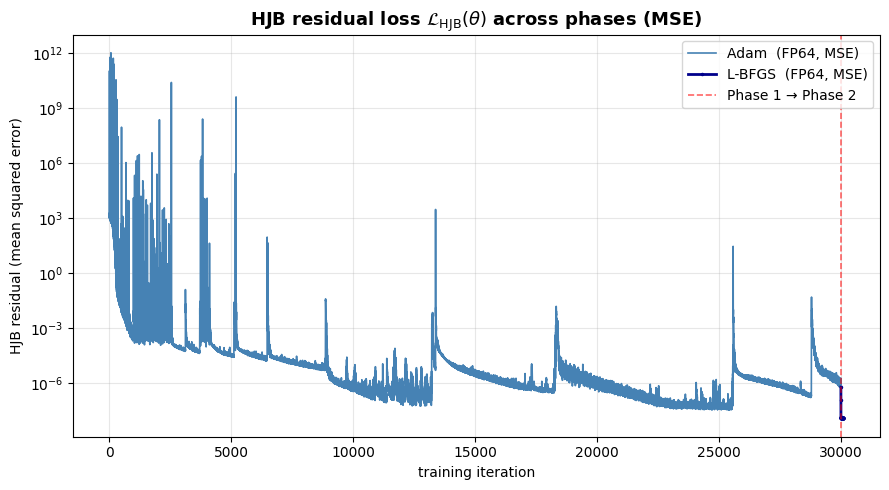


=== Final losses ===
  Phase 1 (Adam)   final HJB (MSE, last epoch) = 9.6316e-07
  Phase 2 (L-BFGS) final HJB (MSE, last iter)  = 1.1410e-08
  L-BFGS reduction factor on HJB               = 8.44e+01×


In [8]:
# =============================================================================
# Cell 7 — Training-loss diagnostics: HJB residual across both phases.
#
# Architecture-agnostic visualisation that only consumes hist_hjb (Phase 1
# Adam) and hist_lbfgs_hjb (Phase 2 L-BFGS). Single-panel semilogy view of
# the HJB residual on a unified iteration axis, with vertical markers at the
# Phase 1 → Phase 2 handoff and any LR-schedule milestones that fired.
# =============================================================================

# ---- Build a unified iteration axis covering both phases ----------------
ep_adam  = np.arange(1, len(hist_hjb) + 1)
ep_lbfgs = np.arange(len(hist_hjb) + 1,
                     len(hist_hjb) + 1 + len(hist_lbfgs_hjb))

# Only annotate LR milestones that actually fired during Phase 1
active_milestones = [ms for ms in LR_MILESTONES if ms < len(hist_hjb)]


# ---- Single-panel semilogy plot -----------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogy(ep_adam,  hist_hjb,       color='steelblue', lw=1.2,
            label='Adam  (FP64, MSE)')
ax.semilogy(ep_lbfgs, hist_lbfgs_hjb, color='darkblue',  lw=2.0,
            marker='.', ms=3, label='L-BFGS  (FP64, MSE)')

# Phase transition marker
ax.axvline(len(hist_hjb), color='red', linestyle='--', alpha=0.6,
           lw=1.2, label='Phase 1 → Phase 2')

# LR-schedule milestones (if any fired)
for i, ms in enumerate(active_milestones):
    ax.axvline(ms, color='k', linestyle='--', alpha=0.4,
               label=f'LR drop ep {ms}' if i == 0 else None)

ax.set_title(r'HJB residual loss $\mathcal{L}_{\mathrm{HJB}}(\theta)$ across phases (MSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('training iteration')
ax.set_ylabel('HJB residual (mean squared error)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('Results_CRRA_homo/loss.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary --------------------------------------------------
print()
print('=== Final losses ===')
print(f'  Phase 1 (Adam)   final HJB (MSE, last epoch) = {hist_hjb[-1]:.4e}')
print(f'  Phase 2 (L-BFGS) final HJB (MSE, last iter)  = {hist_lbfgs_hjb[-1]:.4e}')
print(f'  L-BFGS reduction factor on HJB               = '
      f'{hist_hjb[-1] / hist_lbfgs_hjb[-1]:.2e}×')

---
## Cell 8 — 2D value-function validation: $\widehat V$ vs $V^{\star}$

Architecture-agnostic validation cell. Only calls `net()` (the forward
method), so it works regardless of whether training used NN-direct policies
or FOC substitution — it validates the value function itself, not the
policies.

**Level diagnostic at $(w, y) = (1, 1)$.** Computes
$\widehat K = V^{\star}(1, 1) - \widehat V(1, 1)$. Because the power-of-affine
ansatz bakes in $K^{\star} = -1/((1-\gamma)\delta)$, $\widehat V$ should
already match $V^{\star}$ in level — so $|\widehat K|$ small ($\lesssim 10^{-3}$)
means HJB self-consistency successfully pinned the additive constant on the
homogeneous $(1-\gamma)$-power part without any explicit level pin in the
loss.

**Hard-BC boundary check at $y = Y_{\min}$.** Evaluates
$\widehat V(w, Y_{\min})$ on a 20-point $w$-line and compares to the
closed-form CRRA Merton-with-mortality value. The max and mean absolute
errors should be at machine precision ($\lesssim 10^{-12}$ in FP64); any
larger deviation indicates a bug in the hard-BC architecture rather than a
training failure.

**2D grid heatmaps.** Three side-by-side panels on a $60 \times 60$ grid
spanning $[W_{\min}, 7.0] \times [Y_{\min}, 2.2]$:

- *Left.* Closed-form $V^{\star}(w, y)$.
- *Middle.* Network $\widehat V(w, y)$ on the same colour scale.
- *Right.* Absolute error $|\widehat V - V^{\star}|$ in `hot_r` colormap.

The hard-BC anchor at $y = Y_{\min}$ is overlaid as a dashed horizontal line
in all three panels.

**Numerical summary** reports the max absolute, mean absolute, and relative
$L^2$ errors — the relative $L^2$ is the defendable single-number accuracy
metric.

The figure is saved to `value_function_CRRA.png` for the thesis figure
appendix.

V_hat(1, 1)        = -1.351667
V*(1, 1)           = -1.352214    (closed form, post-hoc)
K_hat              = -0.000547            (level error)
|K_hat|            = 5.4743e-04     (level recovery error from HJB alone)

=== Hard-BC boundary check at y = Y_MIN ===
  max  |V_hat(w, Y_MIN) − V_Merton(w)| = 0.000e+00
  mean |V_hat(w, Y_MIN) − V_Merton(w)| = 0.000e+00
  Hard BC: V_hat(w, 0) = V_BC(w) exactly (modulo numerical precision).



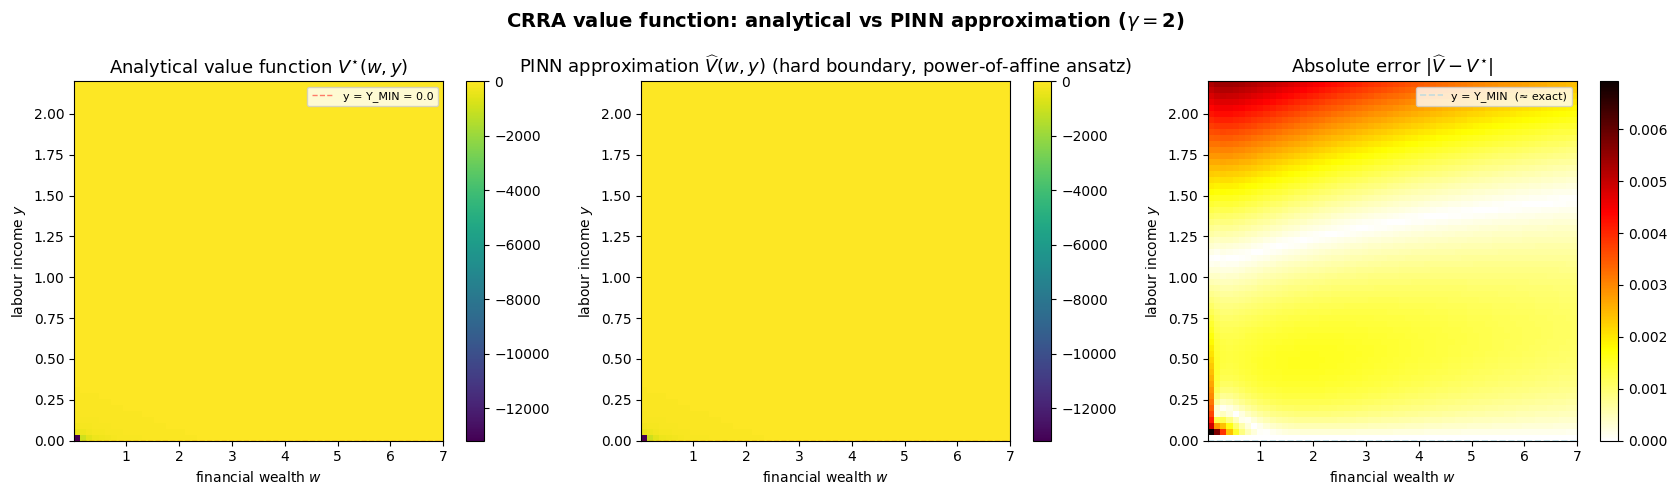

=== 2D grid errors ===
  Unaligned (honest, no level correction):
    Max absolute  = 0.006927
    Mean absolute = 0.001284
    Relative L²   = 0.0007%    ← primary metric



In [9]:
# =============================================================================
# Cell 8 — 2D value-function validation: V_hat vs V* on a grid extending to y = Y_MIN.
#
# Hard-BC trial solution
#     V_hat(w, y) = (φ^γ/(1-γ)) · (w + y · softplus(NN[0]))^(1-γ) + K*.
#
#   • At y = Y_MIN the inner factor reduces to w, so
#     V_hat(w, Y_MIN) = V_BC(w) = (φ^γ/(1-γ)) w^(1-γ) + K*   exactly.
#   • V*(w, y) (closed-form CRRA OLG value) is used here POST-HOC only —
#     it never enters any training loss.
#   • K_hat = V*(1, 1) − V_hat(1, 1) is the level-recovery error: small
#     |K_hat| means HJB self-consistency successfully pinned the additive
#     constant on the homogeneous (1−γ)-power part.
# =============================================================================

net.eval()


# ---- Level diagnostic at reference point (1, 1) -------------------------
W_REF_PLOT = torch.tensor([1.0], device=device, dtype=next(net.parameters()).dtype)
Y_REF_PLOT = torch.tensor([1.0], device=device, dtype=next(net.parameters()).dtype)

with torch.no_grad():
    V_hat_at_11 = float(net(W_REF_PLOT, Y_REF_PLOT).cpu())

K_hat = V_true(1.0, 1.0) - V_hat_at_11                                       # level error: V* − V_hat
print(f'V_hat(1, 1)        = {V_hat_at_11:.6f}')
print(f'V*(1, 1)           = {V_true(1.0, 1.0):.6f}    (closed form, post-hoc)')
print(f'K_hat              = {K_hat:+.6f}            (level error)')
print(f'|K_hat|            = {abs(K_hat):.4e}     (level recovery error from HJB alone)')
print()


# ---- Hard-BC boundary check at y = Y_MIN --------------------------------
# At y = Y_MIN the inner factor is exactly w, so V_hat = V_BC(w) = V_Merton(w).
# Any deviation here is pure float round-off through the autograd graph.
print('=== Hard-BC boundary check at y = Y_MIN ===')
dt_net = next(net.parameters()).dtype
with torch.no_grad():
    w_b        = torch.linspace(W_MIN + 0.05, W_MAX - 0.5, 20, device=device, dtype=dt_net)
    y_b        = torch.full_like(w_b, Y_MIN)
    V_hat_b    = net(w_b, y_b)
    V_Merton_b = (PHI_GAMMA / (1.0 - GAMMA)) * w_b.pow(1.0 - GAMMA) + K_star
    err_b      = (V_hat_b - V_Merton_b).abs()
print(f'  max  |V_hat(w, Y_MIN) − V_Merton(w)| = {err_b.max().item():.3e}')
print(f'  mean |V_hat(w, Y_MIN) − V_Merton(w)| = {err_b.mean().item():.3e}')
print(f'  Hard BC: V_hat(w, 0) = V_BC(w) exactly (modulo numerical precision).')
print()


# ---- 2D grid evaluation -------------------------------------------------
N_GRID = 60
w_grid = np.linspace(W_MIN, 7.0, N_GRID)
y_grid = np.linspace(Y_MIN, 2.2, N_GRID)
WW, YY = np.meshgrid(w_grid, y_grid)

# Closed form on grid
V_cf_grid = V_true(WW, YY)

# Network on grid
with torch.no_grad():
    wf = torch.tensor(WW.ravel(), dtype=dt_net, device=device)
    yf = torch.tensor(YY.ravel(), dtype=dt_net, device=device)
    V_nn_raw = net(wf, yf).cpu().numpy().reshape(N_GRID, N_GRID)

# Errors and relative L² (unaligned = honest, no post-hoc level correction)
err_unaligned = np.abs(V_nn_raw - V_cf_grid)
err_aligned   = np.abs(V_nn_raw + K_hat - V_cf_grid)

rel_L2_raw     = np.sqrt(((V_nn_raw - V_cf_grid)**2).mean()) / np.sqrt((V_cf_grid**2).mean())
rel_L2_aligned = np.sqrt(((V_nn_raw + K_hat - V_cf_grid)**2).mean()) / np.sqrt((V_cf_grid**2).mean())


# ---- 2D heat maps: V*, V_hat, |V_hat − V*| ------------------------------
v_min = min(V_cf_grid.min(), V_nn_raw.min())
v_max = max(V_cf_grid.max(), V_nn_raw.max())

kw   = dict(origin='lower', aspect='auto',
            extent=[w_grid[0], w_grid[-1], y_grid[0], y_grid[-1]])
kw_v = dict(kw, cmap='viridis', vmin=v_min, vmax=v_max)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

im0 = axes[0].imshow(V_cf_grid, **kw_v)
axes[0].set_title(r'Analytical value function $V^{\star}(w, y)$', fontsize=13)
axes[0].set_xlabel('financial wealth $w$'); axes[0].set_ylabel('labour income $y$')
axes[0].axhline(Y_MIN, color='red', alpha=0.5, lw=1.0, ls='--',
                label=f'y = Y_MIN = {Y_MIN}')
axes[0].legend(fontsize=8, loc='upper right')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(V_nn_raw, **kw_v)
axes[1].set_title(r'PINN approximation $\widehat V(w, y)$ (hard boundary, power-of-affine ansatz)', fontsize=13)
axes[1].set_xlabel('financial wealth $w$'); axes[1].set_ylabel('labour income $y$')
axes[1].axhline(Y_MIN, color='red', alpha=0.5, lw=1.0, ls='--')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(err_unaligned, **kw, cmap='hot_r')
axes[2].set_title(r'Absolute error $|\widehat V - V^{\star}|$', fontsize=13)
axes[2].set_xlabel('financial wealth $w$'); axes[2].set_ylabel('labour income $y$')
axes[2].axhline(Y_MIN, color='lightblue', alpha=0.7, lw=1.2, ls='--',
                label='y = Y_MIN  (≈ exact)')
axes[2].legend(fontsize=8, loc='upper right')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(r'CRRA value function: analytical vs PINN approximation ($\gamma = $' + f'{GAMMA:g})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Results_CRRA_homo/V.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary --------------------------------------------------
print('=== 2D grid errors ===')
print(f'  Unaligned (honest, no level correction):')
print(f'    Max absolute  = {err_unaligned.max():.6f}')
print(f'    Mean absolute = {err_unaligned.mean():.6f}')
print(f'    Relative L²   = {rel_L2_raw:.4%}    ← primary metric')
print()

---
## Cell 9.1 — Policies diagnostic: FOC-derived consumption and portfolio (CRRA)

Validates the consumption and portfolio policies derived from $V$ via the
CRRA first-order conditions against the closed-form OLG benchmarks. Matches
the FOC substitution used during Phase 1/2 training, so the policies shown
here are exactly what the loss is optimising — no separate policy heads are
exercised in this validation. The cell uses `net()` autograd, not
`net.forward_policies()`.

**FOC-derived policies.** With $V_w, V_{ww}, V_{wy}$ from autograd through
the trained network and the same clamp safeguards ($V_w \ge 10^{-4}$,
$V_{ww} \le -10^{-3}$) as training:

$$
c_{\mathrm{FOC}}(w, y) \;=\; V_w^{-1/\gamma},
\qquad
\pi_{\mathrm{FOC}}(w, y) \;=\; -\frac{V_w\,(\mu^S - r) + V_{wy}\,\sigma_S \sigma_Y\, y}{V_{ww}\,\sigma_S^2}.
$$

**Closed-form benchmarks** (with $A = w + \varphi^e y$):

$$
c^{\star}(w, y) \;=\; A / \varphi,
\qquad
\pi^{\star}(w, y) \;=\; \frac{\mu^S - r}{\gamma\,\sigma_S^2}\,A
                   \;-\; \frac{\varphi^e \sigma_Y}{\sigma_S}\,y.
$$

**Figure layout (4 panels).**

- *Top row.* 3D surface plots: closed-form policy as a filled colour
  surface (viridis for $c$, plasma for $\pi$) with the FOC-derived policy
  overlaid as a black wireframe. Visual agreement means the two surfaces
  coincide.
- *Bottom row.* 2D heatmaps of the pointwise relative absolute error
  $|c_{\mathrm{FOC}} - c^{\star}|/|c^{\star}|$ and
  $|\pi_{\mathrm{FOC}} - \pi^{\star}|/|\pi^{\star}|$ in percent, with
  99th-percentile clipping on `vmax` to keep the colour scale readable.

**Caveat on the portfolio relative-error heatmap.** $\pi^{\star}(w, y)$
crosses zero along a diagonal in the $(w, y)$ plane (where the labour-hedge
term exactly cancels the Merton long position), so the relative metric is
ill-defined on that locus and inflates artificially near it. The absolute-
error companion plot in Cell 10 is the appropriate accuracy measure for
$\pi$.

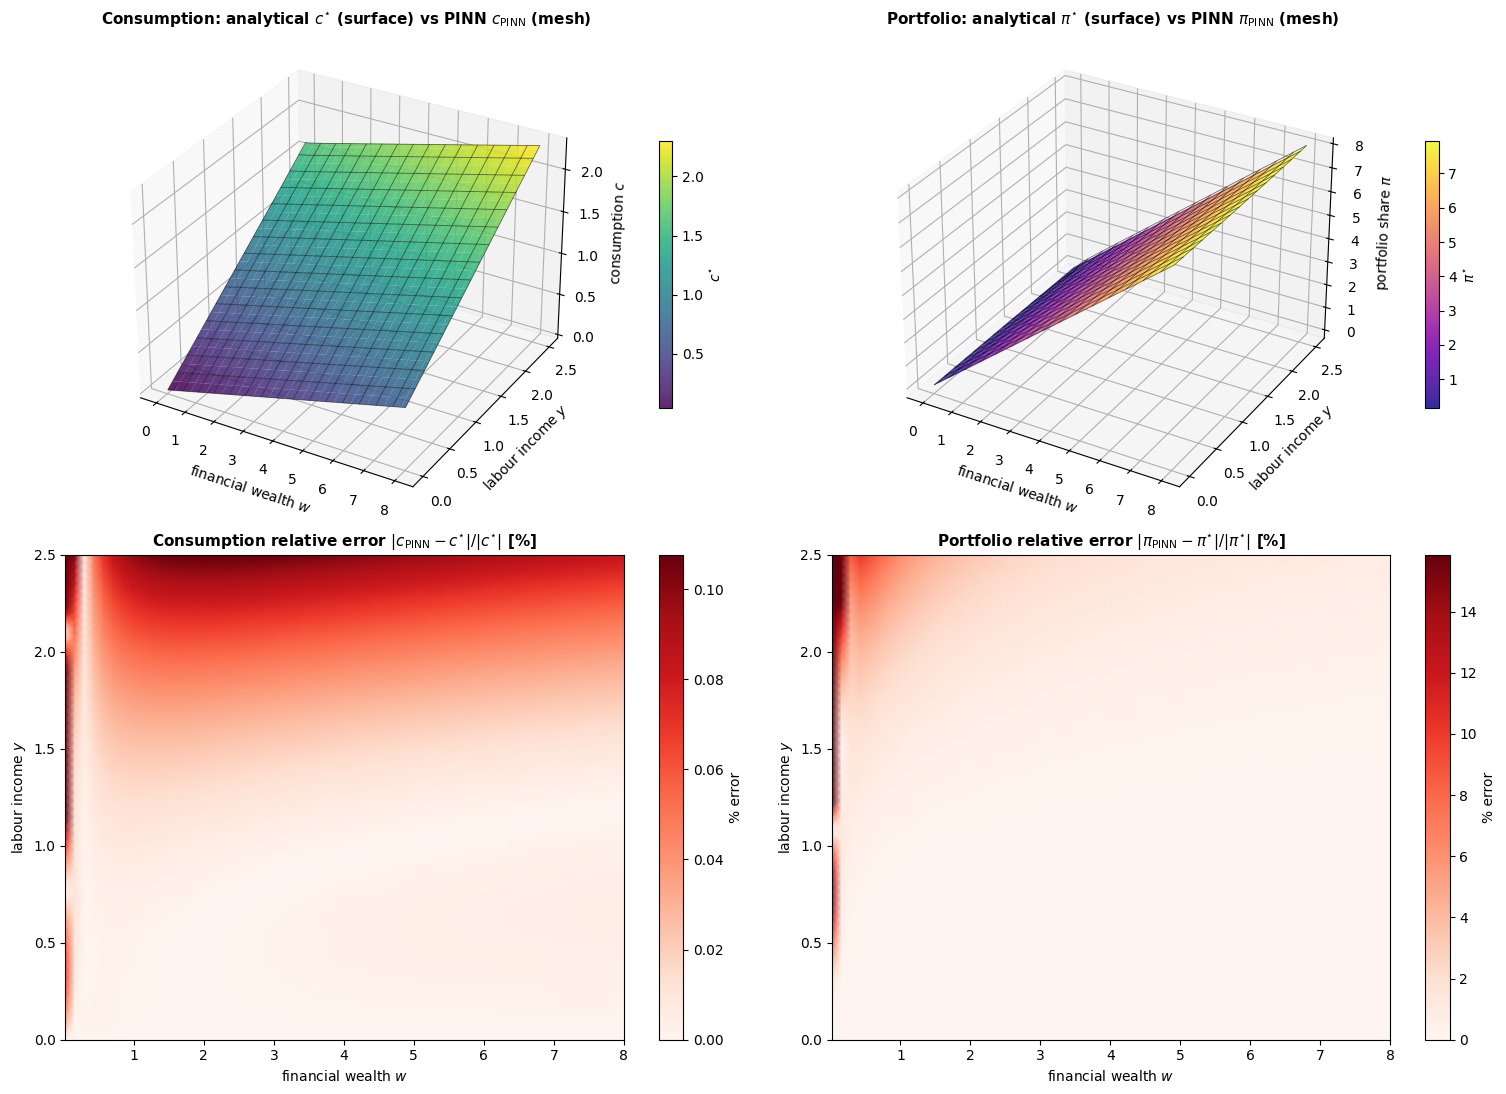

In [10]:
# =============================================================================
# Cell 9.1 — Policies diagnostic (FOC-derived from V, CRRA branch).
#
# Validates the consumption and portfolio policies that emerge from V via
# the CRRA FOCs against the closed-form OLG benchmarks. Matches the
# FOC-substituted residual used during Phase 1/2 training, so the policies
# shown here are exactly what the loss is optimising — no separate policy
# heads are exercised.
#
# Top row:    3D surfaces — closed-form (filled) vs FOC-from-V (black wireframe)
# Bottom row: 2D heatmaps — relative absolute error for c and π separately
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

PI_MERTON_COEF = (mu_S - r_cf) / (GAMMA * sig_S ** 2)         # CRRA Merton coeff (μ^S − r)/(γ σ_S²)


# ---- Evaluation grid ----------------------------------------------------
N_GRID = 60
w_lin = torch.linspace(W_MIN + 0.01, W_MAX, N_GRID,
                       device=device, dtype=torch.float64)
y_lin = torch.linspace(Y_MIN, Y_MAX, N_GRID,
                       device=device, dtype=torch.float64)
W_g, Y_g = torch.meshgrid(w_lin, y_lin, indexing='ij')         # W_g.shape = (N_w, N_y)
w_flat = W_g.reshape(-1).requires_grad_(True)
y_flat = Y_g.reshape(-1).requires_grad_(True)


# ---- Network value + autograd derivatives (V_w, V_ww, V_wy) ------------
V    = net(w_flat, y_flat)
Vw,  = torch.autograd.grad(V,  w_flat, grad_outputs=torch.ones_like(V),  create_graph=True)
Vww, = torch.autograd.grad(Vw, w_flat, grad_outputs=torch.ones_like(Vw), create_graph=True)
Vwy, = torch.autograd.grad(Vw, y_flat, grad_outputs=torch.ones_like(Vw), create_graph=False)

safe_Vw  = Vw.clamp_min(1e-4)
safe_Vww = Vww.clamp_max(-1e-3)


# ---- FOC-substituted policies (CRRA) ------------------------------------
# Consumption:  c = V_w^(-1/γ)
# Portfolio  :  π = − (V_w · (μ^S − r) + V_wy · σ_S σ_Y y) / (V_ww σ_S²)
c_FOC_flat  = safe_Vw.pow(-1.0 / GAMMA)
pi_FOC_flat = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_flat) \
              / (safe_Vww * sig_S ** 2)
c_FOC  = c_FOC_flat.detach().cpu().numpy().reshape(N_GRID, N_GRID)
pi_FOC = pi_FOC_flat.detach().cpu().numpy().reshape(N_GRID, N_GRID)


# ---- Closed-form policies (CRRA OLG, eq. 3.16 + Merton FOC) ------------
W_np    = W_g.detach().cpu().numpy()
Y_np    = Y_g.detach().cpu().numpy()
w_eff   = W_np + phi_e * Y_np                                   # A = w + φ^e y
c_star  = w_eff / phi_cf                                        # c* = A / φ
pi_star = PI_MERTON_COEF * w_eff - (phi_e * sig_Y / sig_S) * Y_np  # π* with labour-income hedge


# ---- Relative absolute errors (in %) -----------------------------------
rel_err_c  = np.abs(c_FOC  - c_star)  / np.abs(c_star)  * 100
rel_err_pi = np.abs(pi_FOC - pi_star) / np.abs(pi_star) * 100


# ---- Plot: 4-panel figure (3D surfaces top, 2D heatmaps bottom) --------
fig = plt.figure(figsize=(15.5, 11.5))

# Top-left: 3D consumption (CF surface + FOC wireframe)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(W_np, Y_np, c_star, cmap='viridis', alpha=0.85,
                          edgecolor='none', antialiased=True,
                          rstride=2, cstride=2)
ax1.plot_wireframe(W_np, Y_np, c_FOC, color='black', alpha=0.55,
                    linewidth=0.6, rstride=4, cstride=4)
ax1.set_xlabel('financial wealth $w$'); ax1.set_ylabel('labour income $y$'); ax1.set_zlabel('consumption $c$')
ax1.set_title(r'Consumption: analytical $c^{\star}$ (surface) vs PINN $c_{\mathrm{PINN}}$ (mesh)',
              fontsize=11, fontweight='bold')
fig.colorbar(surf1, ax=ax1, shrink=0.55, pad=0.10, label=r'$c^{\star}$')

# Top-right: 3D portfolio (CF surface + FOC wireframe)
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
surf2 = ax2.plot_surface(W_np, Y_np, pi_star, cmap='plasma', alpha=0.85,
                          edgecolor='none', antialiased=True,
                          rstride=2, cstride=2)
ax2.plot_wireframe(W_np, Y_np, pi_FOC, color='black', alpha=0.55,
                    linewidth=0.6, rstride=4, cstride=4)
ax2.set_xlabel('financial wealth $w$'); ax2.set_ylabel('labour income $y$'); ax2.set_zlabel(r'portfolio share $\pi$')
ax2.set_title(r'Portfolio: analytical $\pi^{\star}$ (surface) vs PINN $\pi_{\mathrm{PINN}}$ (mesh)',
              fontsize=11, fontweight='bold')
fig.colorbar(surf2, ax=ax2, shrink=0.55, pad=0.10, label=r'$\pi^{\star}$')

# Bottom-left: 2D heatmap of consumption relative error
ax3 = fig.add_subplot(2, 2, 3)
vmax_c = np.percentile(rel_err_c, 99)                           # clip 99th-pct outliers
im3 = ax3.pcolormesh(W_np, Y_np, rel_err_c,
                      cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_c)
ax3.set_xlabel('financial wealth $w$'); ax3.set_ylabel('labour income $y$')
ax3.set_title(r'Consumption relative error $|c_{\mathrm{PINN}}-c^{\star}|/|c^{\star}|$ [%]',
              fontsize=11, fontweight='bold')
fig.colorbar(im3, ax=ax3, label='% error')

# Bottom-right: 2D heatmap of portfolio relative error
ax4 = fig.add_subplot(2, 2, 4)
vmax_pi = np.percentile(rel_err_pi, 99)
im4 = ax4.pcolormesh(W_np, Y_np, rel_err_pi,
                     cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_pi)
ax4.set_xlabel('financial wealth $w$'); ax4.set_ylabel('labour income $y$')
ax4.set_title(r'Portfolio relative error $|\pi_{\mathrm{PINN}}-\pi^{\star}|/|\pi^{\star}|$ [%]',
              fontsize=11, fontweight='bold')
fig.colorbar(im4, ax=ax4, label='% error')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Results_CRRA_homo/policies.png', dpi=150, bbox_inches='tight')
plt.show()




## Cell 9.2 — Portfolio absolute-error heatmap (CRRA case)

Companion diagnostic to Cell 9.1. Reports
$|\pi_{\mathrm{FOC}} - \pi^{\star}|$ in **absolute units** rather than as a
relative percentage, because $\pi^{\star}(w, y)$ crosses zero along a
diagonal in $(w, y)$ space — where the labour-hedge term
$-(\varphi^e \sigma_Y / \sigma_S)\,y$ exactly cancels the Merton long
position $(\mu^S - r) / (\gamma \sigma_S^2) \cdot A$ — and the pointwise
relative metric becomes ill-defined on that locus.



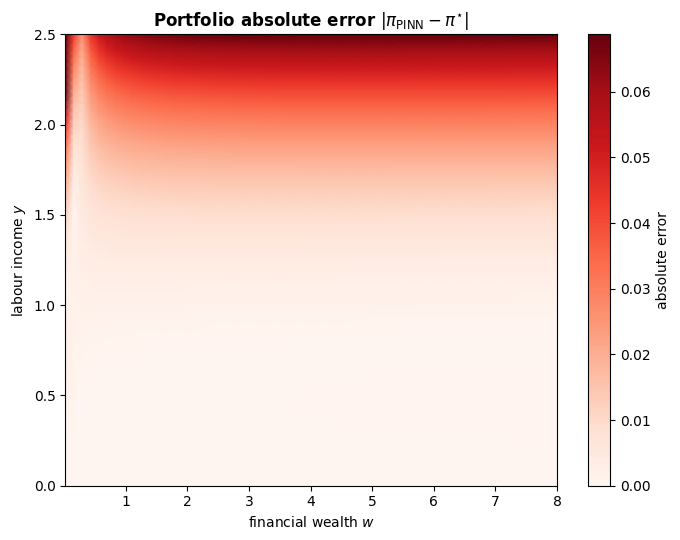

=== Portfolio absolute-error summary (CRRA) ===
  max |π_FOC − π*|        = 0.2214
  mean |π_FOC − π*|       = 0.0139
  max |π*| on the grid    = 8.0000
  mean |π*| on the grid   = 4.0100
  min  |π*| on the grid    = 2.0000e-02
  max-error / max-|π*|    = 2.77%
  relative L²             = 0.52%    ← global accuracy summary


In [11]:
# =============================================================================
# Cell 9.2 — Portfolio absolute-error heatmap (CRRA case).
#
# Companion to Cell 9. Reports |π_FOC − π*| in absolute units rather than as
# a relative %, because π*(w, y) crosses zero along a diagonal in (w, y)
# space (where the labour-hedge term cancels the Merton long position), and
# the pointwise relative metric becomes ill-defined there.
#
# Assumes pi_FOC, pi_star, W_np, Y_np already exist in the namespace
# (computed in the Cell 9 policies diagnostic).
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt


# ---- Heatmap of absolute portfolio error --------------------------------
abs_err_pi = np.abs(pi_FOC - pi_star)

fig, ax = plt.subplots(1, 1, figsize=(7, 5.5))

vmax_pi = np.percentile(abs_err_pi, 99)                        # clip 99th-pct outliers
im = ax.pcolormesh(W_np, Y_np, abs_err_pi,
                   cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_pi)
ax.set_xlabel('financial wealth $w$'); ax.set_ylabel('labour income $y$')
ax.set_title(r'Portfolio absolute error $|\pi_{\mathrm{PINN}}-\pi^{\star}|$',
             fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='absolute error')

plt.tight_layout()
plt.savefig('Results_CRRA_homo/absolute-pi-error.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary --------------------------------------------------
pi_scale_max  = np.abs(pi_star).max()
pi_scale_mean = np.abs(pi_star).mean()
pi_scale_min  = np.abs(pi_star).min()
rel_L2_pi     = np.sqrt((abs_err_pi**2).mean()) / np.sqrt((pi_star**2).mean())

print('=== Portfolio absolute-error summary (CRRA) ===')
print(f'  max |π_FOC − π*|        = {abs_err_pi.max():.4f}')
print(f'  mean |π_FOC − π*|       = {abs_err_pi.mean():.4f}')
print(f'  max |π*| on the grid    = {pi_scale_max:.4f}')
print(f'  mean |π*| on the grid   = {pi_scale_mean:.4f}')
print(f'  min  |π*| on the grid    = {pi_scale_min:.4e}')
print(f'  max-error / max-|π*|    = {abs_err_pi.max() / pi_scale_max:.2%}')
print(f'  relative L²             = {rel_L2_pi:.2%}    ← global accuracy summary')




---
## Cell 10 — Wealth-to-consumption ratio diagnostic (CRRA)

Compares the closed-form wealth-to-consumption ratio
$w / c^{\star}(w, y) = w \cdot \varphi / (w + \varphi^e y)$
to the FOC-derived ratio
$w / c_{\mathrm{FOC}}(w, y) = w \cdot V_w(w, y)^{1/\gamma}$
on a 2D grid, with a hard-BC anchor check at $y = 0$ (the ratio must equal
the CRRA Merton constant $\varphi$ there, *independently of $w$*).

**Why W2C is the right diagnostic.** The ratio isolates the intertemporal-
substitution structure from the level of $c$, and is sensitive to $V_w$
accuracy specifically (not just $V$ itself). It complements Cell 8 (which
validates $V$) and Cells 9–10 (which validate $c$ and $\pi$).

**Hard-BC anchor at $y = 0$.** At $y = 0$ the value function is forced to
the CRRA Merton form
$V_{\mathrm{BC}}(w) = (\varphi^{\gamma}/(1-\gamma))\, w^{1-\gamma} + K^{\star}$
by the architecture, so $V_w(w, 0) = \varphi^{\gamma}\, w^{-\gamma}$
exactly, and $c_{\mathrm{FOC}}(w, 0) = V_w^{-1/\gamma} = w / \varphi$.
Therefore $w / c_{\mathrm{FOC}}(w, 0) = \varphi$ for all $w$. If the
printed $\max |w/c - \varphi|$ at $y = 0$ comes in at $\sim 10^{-5}$ or
smaller, the hard BC is being honoured at the $V_w$ level (not just at
$V$). Larger values would indicate the BC anchor is intact at $V$ but
drifting in its first derivative.

**Architectural coupling.** Uses `compute_all_derivatives` and the same
$V_w$ clamp safeguard as training, so the diagnostic measures exactly what
the FOC-substituted residual optimises.

**Figure layout (2 panels).**

- *Left.* 3D surface: closed-form $w/c$ as a filled viridis colour surface
  with the FOC-derived ratio overlaid as a black wireframe. View angle
  $(\text{elev} = 22,\, \text{azim} = -55)$ chosen so the ridge at $y = 0$
  — where $w/c \to \varphi$ — is visible from the front.
- *Right.* 2D heatmap of relative absolute error with 99th-percentile
  clipping on `vmax` and a max/mean error box overlaid.

The figure is saved to `w2c_ratio_CRRA.png` for the thesis figure appendix.

**Numerical summary** reports the max-abs, mean-abs, max-rel, mean-rel
errors and the relative $L^2$ on the full grid, then the y = 0 BC anchor
check $|w/c - \varphi|$ as a separate section.

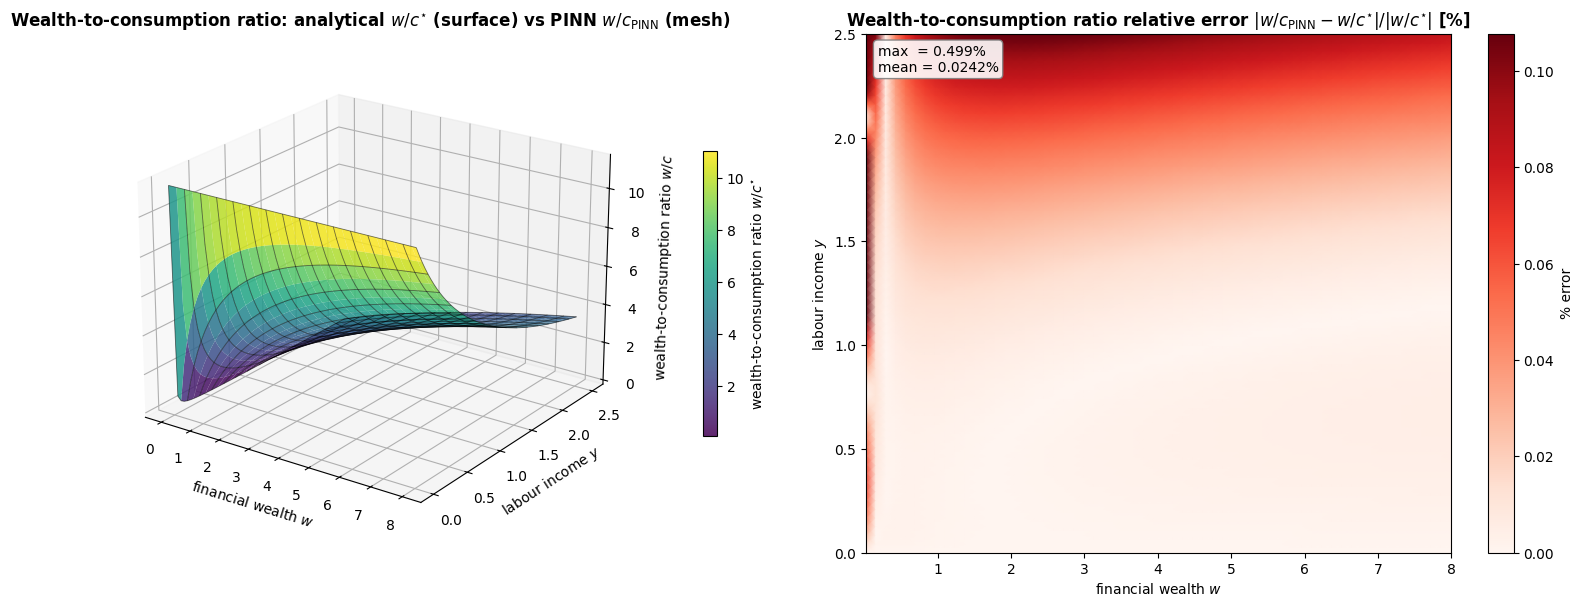


=== W2C ratio agreement (full grid, FOC-derived from V) ===
  max abs error          = 0.0029
  mean abs error         = 0.0005
  max rel error          = 0.499%
  mean rel error         = 0.0242%
  relative L²            = 0.0171%    ← global accuracy summary

=== Hard-BC anchor at y = 0.0 (CRRA Merton-with-mortality limit) ===
  Expected w/c           = φ = 11.48782
  Mean w/c (FOC, y = 0)  = 11.48782
  Max |w/c − φ| at y = 0 = 0.00000


In [12]:
# =============================================================================
# Cell 10 — Wealth-to-consumption ratio diagnostic (CRRA Hard-BC PINN).
#
# Compares the closed-form W2C ratio
#     w / c*(w, y) = w · φ / (w + φ^e y)
# to the FOC-derived ratio
#     w / c_FOC(w, y) = w · V_w(w, y)^(1/γ)
# on a 2D grid, with a hard-BC anchor check at y = 0 (the ratio must equal
# the CRRA Merton constant φ there, independently of w).
#
# Side benefit: the ratio diagnostic isolates the intertemporal-substitution
# structure from the level of c, and is sensitive to V_w accuracy
# specifically (not just V itself).
#
# c is derived from V via FOC (c = V_w^(-1/γ), CRRA), NOT from a policy head.
# =============================================================================
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 (registers '3d' projection)

dt_net = next(net.parameters()).dtype
net.eval()


# ---- FOC-derived consumption helper -------------------------------------
def c_FOC_array(w, y):
    """Return c = V_w^(−1/γ) on numpy inputs via autograd through the trained
    net (CRRA FOC), applying the same V_w clamp safeguard used in training.
    """
    w_t = torch.as_tensor(w, dtype=dt_net, device=device).clone().requires_grad_(True)
    y_t = torch.as_tensor(y, dtype=dt_net, device=device).clone().requires_grad_(True)
    _, Vw, _, _, _, _, _, _ = compute_all_derivatives(net, w_t, y_t)
    safe_Vw = Vw.clamp_min(1e-4)
    return safe_Vw.pow(-1.0 / GAMMA).detach().cpu().numpy()


# ---- Evaluation grid -----------------------------------------------------
N_GRID = 60
w_lin = np.linspace(W_MIN + 0.01, W_MAX, N_GRID)
y_lin = np.linspace(Y_MIN, Y_MAX, N_GRID)
W_g, Y_g = np.meshgrid(w_lin, y_lin, indexing='xy')             # W_g.shape = (N_y, N_w)


# ---- Closed-form and FOC-derived W2C ratios -----------------------------
# Closed form: c*(w, y) = (w + φ^e y) / φ,  so  w / c* = w · φ / (w + φ^e y).
C_cf  = (W_g + phi_e * Y_g) / phi_cf
W2C_cf = W_g / C_cf

# FOC-derived: c_FOC = V_w^(−1/γ), evaluated through the trained network.
C_nn  = c_FOC_array(W_g.ravel(), Y_g.ravel()).reshape(N_GRID, N_GRID)
W2C_nn = W_g / C_nn


# ---- Relative absolute error (%) ----------------------------------------
rel_err_w2c = np.abs(W2C_nn - W2C_cf) / np.maximum(np.abs(W2C_cf), 1e-6) * 100


# ---- Figure: 3D surface (left) + 2D relative-error heatmap (right) ------
fig = plt.figure(figsize=(15.5, 6.5))

# Left: 3D surface (CF coloured + FOC black wireframe)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(W_g, Y_g, W2C_cf, cmap='viridis', alpha=0.85,
                         edgecolor='none', antialiased=True,
                         rstride=2, cstride=2)
ax1.plot_wireframe(W_g, Y_g, W2C_nn, color='black', alpha=0.55,
                    linewidth=0.6, rstride=4, cstride=4)
ax1.set_xlabel('financial wealth $w$'); ax1.set_ylabel('labour income $y$'); ax1.set_zlabel('wealth-to-consumption ratio $w/c$')
ax1.set_title(r'Wealth-to-consumption ratio: analytical $w/c^{\star}$ (surface) vs PINN $w/c_{\mathrm{PINN}}$ (mesh)',
              fontsize=12, fontweight='bold')
ax1.view_init(elev=22, azim=-55)
fig.colorbar(surf, ax=ax1, shrink=0.55, pad=0.10, label=r'wealth-to-consumption ratio $w/c^{\star}$')

# Right: 2D heatmap of relative absolute error
ax2 = fig.add_subplot(1, 2, 2)
vmax_w2c = np.percentile(rel_err_w2c, 99)                       # clip 99th-pct outliers
im2 = ax2.pcolormesh(W_g, Y_g, rel_err_w2c,
                      cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_w2c)
ax2.set_xlabel('financial wealth $w$'); ax2.set_ylabel('labour income $y$')
ax2.set_title(r'Wealth-to-consumption ratio relative error $|w/c_{\mathrm{PINN}} - w/c^{\star}| / |w/c^{\star}|$ [%]',
              fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=ax2, label='% error')
ax2.text(0.02, 0.98,
         f'max  = {rel_err_w2c.max():.3f}%\nmean = {rel_err_w2c.mean():.4f}%',
         transform=ax2.transAxes, va='top', ha='left', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white',
                   alpha=0.9, edgecolor='gray'))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Results_CRRA_homo/WCR.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary --------------------------------------------------
err_w2c    = np.abs(W2C_nn - W2C_cf)
rel_L2_w2c = np.sqrt(((W2C_nn - W2C_cf)**2).mean()) / np.sqrt((W2C_cf**2).mean())

print()
print('=== W2C ratio agreement (full grid, FOC-derived from V) ===')
print(f'  max abs error          = {err_w2c.max():.4f}')
print(f'  mean abs error         = {err_w2c.mean():.4f}')
print(f'  max rel error          = {rel_err_w2c.max():.3f}%')
print(f'  mean rel error         = {rel_err_w2c.mean():.4f}%')
print(f'  relative L²            = {rel_L2_w2c:.4%}    ← global accuracy summary')

print()
print(f'=== Hard-BC anchor at y = {Y_MIN} (CRRA Merton-with-mortality limit) ===')
print(f'  Expected w/c           = φ = {phi_cf:.5f}')
print(f'  Mean w/c (FOC, y = 0)  = {W2C_nn[0, :].mean():.5f}')
print(f'  Max |w/c − φ| at y = 0 = {np.abs(W2C_nn[0, :] - phi_cf).max():.5f}')